In [8]:
import pandas as pd
import matplotlib.pyplot as plt

import pickle
from matplotlib.gridspec import GridSpec

import multiprocessing as mp

## Data sets used

### Ioro data: 
 - Ioro data:  [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.7794546.svg)](https://doi.org/10.5281/zenodo.7794546) 
### Van Son Data 
 - van Son data [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.14508864.svg)](https://doi.org/10.5281/zenodo.14508864) 
 
 ### Neijssel 2019: 
 - we used a webdigitizer to digitalize the data from their Figure 1 
 
 ### Broekgaarden 2022: 
 - we use the data from this Zenodo: 
    
    

### Combined plot for Paper 

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import h5py as h5

sys.path.append('../../../common_code')

#Custom imports
# for color map
import seaborn as sns
# for reading datafiles 
import pandas as pd

# import script that has formation channel classification functions:
from PostProcessingScripts import * 


from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


Zenodo_data_dir = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/data_for_formation_efficiency'

# Check if the yield data dictionary exists
if os.path.isfile(f'{Zenodo_data_dir}/vanSon23_yield_data.pkl'):
    print(f'reading in {Zenodo_data_dir}/vanSon23_yield_data.pkl ')
    with open(f'{Zenodo_data_dir}/vanSon23_yield_data.pkl', 'rb') as f:
        yield_data = pickle.load(f)
else:
    #########################
    print('datafile not found')
    
    
    
# Dictionary to map simulation names to labels and colors we want to use in the plots
sim_name_dict = {
    'NewWinds_RemFryer2012': ['Fiducial', '#5c5c5c', '-.', 'o', 8], 
    'NewWinds_RemMullerMandel': ['MM remnant', '#82BD4D', '-.', '', 4.5],
    'NewWinds_RemFryer2012_noNSBHkick': ['No natal kicks', '#FECC6A', '-.', 'x',4.5],
    'NewWinds_RemFryer2012_noWRwinds': ['No WR winds', '#0597f2', '--', '*',4],
    'NewWinds_RemFryer2012_noMSwinds': ['No MS winds', '#78ccc8', '--', '.',3.5],
    'NewWinds_RemFryer2012_oldRSG': ['Old RSG ', '#C3375A', ':', '',3.5],
    'OldWinds_RemFryer2012': ['Old Winds', '#FF9E7B', ':', 'p',2.5],
    }

# List of DCO flavors
DCO_flavors         = ["BBH", "BHNS", "NSNS"]




# ============================================================
# PATHS / INPUTS
# ============================================================

# ---------- Iorio ----------
iorio_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"
iorio_model_dic = {
    "F": os.path.join(iorio_loc, "simulation_F"),
    "QCBSE": os.path.join(iorio_loc, "simulation_QCBSE"),
    "QCBB": os.path.join(iorio_loc, "simulation_QCBB"),
    "RBSE": os.path.join(iorio_loc, "simulation_RBSE"),
    "NTC": os.path.join(iorio_loc, "simulation_NTC"),
    "NT": os.path.join(iorio_loc, "simulation_NT"),
    "QHE": os.path.join(iorio_loc, "simulation_QHE"),
    "F19": os.path.join(iorio_loc, "simulation_F19"),
    "K150": os.path.join(iorio_loc, "simulation_K150"),
    "K265": os.path.join(iorio_loc, "simulation_K265"),
    "LX": os.path.join(iorio_loc, "simulation_LX"),
    "LK": os.path.join(iorio_loc, "simulation_LK"),
    "LC": os.path.join(iorio_loc, "simulation_LC"),
    "SND": os.path.join(iorio_loc, "simulation_SND"),
    "OPT": os.path.join(iorio_loc, "simulation_OPT"),
    "F5M": os.path.join(iorio_loc, "simulation_F5M"),
}

# ---------- Broekgaarden ----------
broek_csvPath = "/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/"
broek_models_to_plot = None   # plot all

# ---------- van Son ----------
# assumes sim_name_dict and yield_data are already loaded in memory




reading in /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/data_for_formation_efficiency/vanSon23_yield_data.pkl 


In [109]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================================================
# USER COLORS
# ============================================================
COLORS = {
    "orange_light": "#FFD08A",  # stable only for van Son BBH without-CE
    "orange_main":  "#FFA630",  # without CE
    "blue_main":    "#00A7E1",  # with CE
}

LABEL_SIZE = 11
TITLE_SIZE = 13

# ============================================================
# GLOBAL PLOT STYLE
# ============================================================
LINEWIDTH_MAIN = 1.2
LINEWIDTH_SECONDARY = 1.0   # for BBH stable-only van Son line

MARKERSIZE_MAIN = 3.0
MARKERSIZE_VANSON = 3.0
MARKERSIZE_SECONDARY = 2.6

ALPHA_MAIN = 1
ALPHA_SECONDARY = 0.8

tick_length =4

# ============================================================
# IORIO PART
# ============================================================

def iorio_compute_collapsed_fractions(
    df,
    alpha,
    bco_type,
    min_with_ce_count_bns=1,
    min_total_count_bns=1,
    mask_zero_bns=True,
):
    """
    Return fractions as a function of Z:
      with_CE    = CI + CIII + CIV
      without_CE = CII
      others     = 1 - (with_CE + without_CE)
    """
    sub = df[df["alpha"] == alpha].sort_values("Z")
    if sub.empty:
        return None

    z = sub["Z"].to_numpy(dtype=float)
    tot = sub[bco_type].to_numpy(dtype=float)
    ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
    cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
    ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
    civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

    with_ce_count = ci + ciii + civ

    with np.errstate(divide="ignore", invalid="ignore"):
        f_i = np.divide(ci, tot, out=np.full_like(ci, np.nan), where=tot > 0)
        f_ii = np.divide(cii, tot, out=np.full_like(cii, np.nan), where=tot > 0)
        f_iii = np.divide(ciii, tot, out=np.full_like(ciii, np.nan), where=tot > 0)
        f_iv = np.divide(civ, tot, out=np.full_like(civ, np.nan), where=tot > 0)

    f_with_ce = f_i + f_iii + f_iv
    f_without_ce = f_ii
    f_others = 1.0 - (f_with_ce + f_without_ce)

    if bco_type in {"NSNS", "NSNSm"}:
        bad = np.zeros_like(z, dtype=bool)
        if min_with_ce_count_bns is not None:
            bad |= (with_ce_count < min_with_ce_count_bns)
        if min_total_count_bns is not None:
            bad |= (tot < min_total_count_bns)
        if mask_zero_bns:
            bad |= (with_ce_count <= 0)

        f_with_ce = f_with_ce.astype(float)
        f_with_ce[bad] = np.nan

    return {
        "Z": z,
        "logZ": np.log10(z),
        "with_CE": f_with_ce,
        "without_CE": f_without_ce,
        "others": f_others,
    }


def plot_iorio_panel(
    ax,
    model_dic,
    which_fraction="with_CE",
    bco_type="BHBHm",
):
    color = COLORS["blue_main"] if which_fraction == "with_CE" else COLORS["orange_main"]

    all_alphas = set()
    for _, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if os.path.exists(summary_file):
            df = pd.read_csv(summary_file)
            all_alphas.update(df["alpha"].dropna().unique())
    all_alphas = sorted(all_alphas)

    linestyle_cycle = ["-", "--", "-.", ":"]
    alpha_linestyles = {
        alpha: linestyle_cycle[i % len(linestyle_cycle)]
        for i, alpha in enumerate(all_alphas)
    }

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
    model_names = list(model_dic.keys())
    model_markers = {
        model: marker_cycle[i % len(marker_cycle)]
        for i, model in enumerate(model_names)
    }

    for model, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if not os.path.exists(summary_file):
            print(f"Warning: missing file {summary_file}")
            continue

        df = pd.read_csv(summary_file)
        alphas = sorted(df["alpha"].dropna().unique())

        for alpha in alphas:
            result = iorio_compute_collapsed_fractions(df, alpha, bco_type)
            if result is None:
                continue

            ax.plot(
                result["logZ"],
                result[which_fraction],
                color=color,
                linestyle=alpha_linestyles[alpha],
                marker=model_markers[model],
                ms=MARKERSIZE_MAIN,
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
            )

    ax.set_xlim(-4.1, -1.45)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True, length=tick_length)


# ============================================================
# BROEKGAARDEN PART
# ============================================================

def load_grouped_formation_channels(
    df,
    bps_model,
    headerDict_Z_rev,
    include_vii_in_with_CE=False,
):
    ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

    with_CE = ch_classic + ch_immed + ch_double
    if include_vii_in_with_CE:
        with_CE = with_CE + ch_vii

    without_CE = ch_stable
    other = ch_other

    total = with_CE + without_CE + other
    if not include_vii_in_with_CE:
        total = total + ch_vii

    return {
        "with_CE": with_CE,
        "without_CE": without_CE,
        "other": other,
        "total": total,
        "vii": ch_vii,
    }


def get_grouped_fraction_or_yield(grouped, grouped_key="with_CE", plot_fraction=True):
    y = np.asarray(grouped[grouped_key], dtype=float)
    total = np.asarray(grouped["total"], dtype=float)

    if plot_fraction:
        yplot = np.divide(
            y,
            total,
            out=np.full_like(y, np.nan, dtype=float),
            where=(total > 0)
        )
    else:
        yplot = y * 1e5

    return yplot, total


def mask_low_total_points(yplot, total, min_total=0.0):
    ymasked = np.array(yplot, copy=True)
    ymasked[total <= min_total] = np.nan
    return ymasked


def plot_broekgaarden_panel(
    ax,
    csvPath,
    DCOtype="BBH",
    grouped_key="with_CE",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,
    models_to_plot=None,
):
    color = COLORS["blue_main"] if grouped_key == "with_CE" else COLORS["orange_main"]

    dictDCOtypeDCOlabel = {
        "BBH": "BHBH",
        "BHNS": "BHNS",
        "BNS": "NSNS",
    }

    if models_to_plot is None:
        models_to_plot = list(string.ascii_uppercase[:nModels])

    log10metallicities = np.log10(np.asarray(metallicities_list, dtype=float))

    csv_file = os.path.join(
        csvPath,
        f"formation_channels_per_Z_hdf5weights_{dictDCOtypeDCOlabel[DCOtype]}.csv"
    )
    df = pd.read_csv(csv_file, index_col=0)

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
    linestyle_cycle = ["-", "--", "-.", ":"]

    model_markers = {
        model: marker_cycle[i % len(marker_cycle)]
        for i, model in enumerate(models_to_plot)
    }
    model_linestyles = {
        model: linestyle_cycle[i % len(linestyle_cycle)]
        for i, model in enumerate(models_to_plot)
    }

    for bps_model in models_to_plot:
        grouped = load_grouped_formation_channels(
            df=df,
            bps_model=bps_model,
            headerDict_Z_rev=headerDict_Z_rev,
            include_vii_in_with_CE=include_vii_in_with_CE,
        )

        yplot, total = get_grouped_fraction_or_yield(
            grouped,
            grouped_key=grouped_key,
            plot_fraction=plot_fraction,
        )

        if min_total_mask is not None:
            yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

        ax.plot(
            log10metallicities,
            yplot,
            lw=LINEWIDTH_MAIN,
            linestyle=model_linestyles[bps_model],
            marker=model_markers[bps_model],
            ms=MARKERSIZE_MAIN,
            color=color,
            alpha=ALPHA_MAIN,
        )

    ax.set_xlim(-4.1, -1.45)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True, length=tick_length)


# ============================================================
# VAN SON PART
# Requires:
# - sim_name_dict
# - yield_data
# - DCO_flavors = ['BBH', 'BHNS', 'NSNS']  (or compatible names)
# ============================================================

def vanson_get_fraction_arrays(data, flavor):
    flav_data = data[flavor]

    ce_vals = np.asarray(flav_data["CE_group_lengths"], dtype=float)
    stable_vals = np.asarray(flav_data["stable_group_lengths"], dtype=float)

    if "CHEstable_group_lengths" in flav_data:
        che_vals = np.asarray(flav_data["CHEstable_group_lengths"], dtype=float)
    else:
        che_vals = np.zeros_like(ce_vals)

    is_bbh = flavor == "BBH"

    denom_main = ce_vals + stable_vals + che_vals if is_bbh else ce_vals + stable_vals
    denom_no_che = ce_vals + stable_vals

    with np.errstate(divide="ignore", invalid="ignore"):
        with_ce = np.divide(
            ce_vals, denom_main,
            out=np.full_like(ce_vals, np.nan, dtype=float),
            where=denom_main > 0,
        )

        without_ce = np.divide(
            stable_vals + che_vals if is_bbh else stable_vals,
            denom_main,
            out=np.full_like(stable_vals, np.nan, dtype=float),
            where=denom_main > 0,
        )

        with_ce_no_che = np.divide(
            ce_vals, denom_no_che,
            out=np.full_like(ce_vals, np.nan, dtype=float),
            where=denom_no_che > 0,
        )

        without_ce_stable_only = np.divide(
            stable_vals, denom_no_che,
            out=np.full_like(stable_vals, np.nan, dtype=float),
            where=denom_no_che > 0,
        )

    return {
        "with_CE": with_ce,
        "without_CE": without_ce,
        "with_CE_no_CHE": with_ce_no_che,
        "without_CE_stable_only": without_ce_stable_only if is_bbh else None,
    }


def plot_vanson_panel(
    ax,
    which_fraction="with_CE",
    flavor="BBH",
    sim_name_dict=None,
    yield_data=None,
):
    """
    Plot one van Son panel.

    Special case:
    - For BBH + without_CE:
      plot stable only in light orange
      and stable+CHE in orange_main
    """
    zvals_set = False

    for sim_name, (Lab, _, lines, mark, LW) in sim_name_dict.items():
        data = yield_data[sim_name]
        zvals = np.log10(data["Z_values"] / 0.014) + np.log10(0.014)
        zvals_set = True

        fracs = vanson_get_fraction_arrays(data, flavor)

        if which_fraction == "with_CE":
            # Main with-CE line: CE / (CE + stable + CHE)
            ax.plot(
                zvals,
                fracs["with_CE"],
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
                ls=lines,
                color=COLORS["blue_main"],
                marker=mark,
                markevery=2,
                markersize=MARKERSIZE_MAIN,
            )

            # Extra no-CHE line for BBH:
            # CE / (CE + stable)
            if flavor == "BBH" and fracs["with_CE_no_CHE"] is not None:
                ax.plot(
                    zvals,
                    fracs["with_CE_no_CHE"],
                    lw=LINEWIDTH_SECONDARY,
                    alpha=ALPHA_SECONDARY,
                    ls="--",
                    color="gray",
                    marker=mark,
                    markevery=2,
                    markersize=MARKERSIZE_SECONDARY,
                )

        elif which_fraction == "without_CE":
            # Main without-CE line
            ax.plot(
                zvals,
                fracs["without_CE"],
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
                ls="--",
                color=COLORS["orange_main"],
                marker=mark,
                markevery=2,
                markersize=MARKERSIZE_MAIN,
            )

            # Extra conservative stable-only line for BBH
            if flavor == "BBH" and fracs["without_CE_stable_only"] is not None:
                ax.plot(
                    zvals,
                    fracs["without_CE_stable_only"],
                    lw=LINEWIDTH_SECONDARY,
                    alpha=ALPHA_SECONDARY,
                    ls="--",
                    color="gray",
                    marker=mark,
                    markevery=2,
                    markersize=MARKERSIZE_SECONDARY,
                )

    if zvals_set:
        ax.set_xlim(-4.1, -1.45)

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True, length=tick_length)


    return 

### Neijssel plot for BBHs 

def plot_neijssel_bbh_panel(
    ax,
    processed_digitized_csv,
    which_fraction="with_CE",
):
    """
    Plot Neijssel+2019 digitized BBH formation-channel fractions.

    Assumes processed_digitized_csv has:
      log10Z_Zsun, Channel_I, Channel_II, Channel_III

    with_CE    = Channel_I + Channel_III
    without_CE = Channel_II
    """
    dfd = pd.read_csv(processed_digitized_csv)

    for col in ["Channel_I", "Channel_II", "Channel_III"]:
        dfd[col] = pd.to_numeric(dfd[col], errors="coerce").clip(lower=0)

    dfd["Total"] = dfd["Channel_I"] + dfd["Channel_II"] + dfd["Channel_III"]
    dfd["with_CE"] = dfd["Channel_I"] + dfd["Channel_III"]
    dfd["without_CE"] = dfd["Channel_II"]

    dfd["f_with_CE"] = np.divide(
        dfd["with_CE"], dfd["Total"],
        out=np.full(len(dfd), np.nan),
        where=(dfd["Total"] > 0),
    )

    dfd["f_without_CE"] = np.divide(
        dfd["without_CE"], dfd["Total"],
        out=np.full(len(dfd), np.nan),
        where=(dfd["Total"] > 0),
    )
    
    # convert to nplog10(Z) instead of divided by Zsun
    Zsun = 0.014  
    logZsun = np.log10(Zsun)
    dfd["log10Z"] = dfd["log10Z_Zsun"] + logZsun
    dfd = dfd.sort_values("log10Z")

    ycol = "f_with_CE" if which_fraction == "with_CE" else "f_without_CE"

    color = COLORS["blue_main"] if which_fraction == "with_CE" else COLORS["orange_main"]

    ax.plot(
        dfd["log10Z"],
        dfd[ycol],
        color=color,
        lw=LINEWIDTH_MAIN,
        alpha=ALPHA_MAIN,
        ls="-",
    )

    ax.scatter(
        dfd["log10Z"],
        dfd[ycol],
        facecolor=color,
        edgecolor=color,
        marker='s',
        s=MARKERSIZE_MAIN**2,   # match visual size better
        zorder=3,
    )

    ax.set_xlim(-4.1, -1.45)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        length=3,
    )
    
    
    # Add inline label (only once per panel)
    if len(dfd) > 0:
        x_last = dfd["log10Z"].iloc[0]
        y_last = dfd[ycol].iloc[0]

        color = COLORS["blue_main"] if which_fraction == "with_CE" else COLORS["orange_main"]

        ax.text(
            x_last + 0.0,   # small shift to the right
            y_last+0.14,
            "Neijssel",
            color=color,
            fontsize=9,
            va="center",
        )


    return 





In [110]:
def make_combined_ce_figure_3x6(
    iorio_model_dic,
    broek_csvPath,
    sim_name_dict,
    yield_data,
    processed_digitized_csv=None,
    include_vii_in_with_CE=False,
    broek_plot_fraction=True,
    broek_min_total_mask=0.0,
    broek_models_to_plot=None,
    figsize=(18, 8.2),
    savefile=None,
):
    """
    Create a 4 x 6 figure:
      row 1 = Iorio
      row 2 = Broekgaarden
      row 3 = van Son
      row 4 = Other studies

    cols 1-3 = with_CE    for BBH, BHNS, BNS
    cols 4-6 = without_CE for BBH, BHNS, BNS
    """
    fig, axes = plt.subplots(
        nrows=4,
        ncols=6,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    fraction_order = [
        ("with_CE", COLORS["blue_main"]),
        ("without_CE", COLORS["orange_main"]),
    ]

    row_configs = [
        {
            "row": 0,
            "study": "Iorio",
            "items": [("BHBHm", "BBH"), ("BHNSm", "BHNS"), ("NSNSm", "BNS")],
            "plotter": lambda ax, item, which_fraction: plot_iorio_panel(
                ax=ax,
                model_dic=iorio_model_dic,
                which_fraction=which_fraction,
                bco_type=item,
            ),
        },
        {
            "row": 1,
            "study": "Broekgaarden",
            "items": [("BBH", "BBH"), ("BHNS", "BHNS"), ("BNS", "BNS")],
            "plotter": lambda ax, item, which_fraction: plot_broekgaarden_panel(
                ax=ax,
                csvPath=broek_csvPath,
                DCOtype=item,
                grouped_key=which_fraction,
                include_vii_in_with_CE=include_vii_in_with_CE,
                plot_fraction=broek_plot_fraction,
                min_total_mask=broek_min_total_mask,
                models_to_plot=broek_models_to_plot,
            ),
        },
        {
            "row": 2,
            "study": "van Son",
            "items": [("BBH", "BBH"), ("BHNS", "BHNS"), ("NSNS", "BNS")],
            "plotter": lambda ax, item, which_fraction: plot_vanson_panel(
                ax=ax,
                which_fraction=which_fraction,
                flavor=item,
                sim_name_dict=sim_name_dict,
                yield_data=yield_data,
            ),
        },
        {
            "row": 3,
            "study": "Other studies",
            "items": [("BBH", "BBH"), ("BHNS", "BHNS"), ("BNS", "BNS")],
            "plotter": lambda ax, item, which_fraction: (
                plot_neijssel_bbh_panel(
                    ax=ax,
                    processed_digitized_csv=processed_digitized_csv,
                    which_fraction=which_fraction,
                )
                if item == "BBH" and processed_digitized_csv is not None
                else None
            ),
        },
    ]

    # -------------------------------------------------
    # Fill all panels
    # -------------------------------------------------
    for config in row_configs:
        row = config["row"]

        for block_idx, (which_fraction, _) in enumerate(fraction_order):
            col_offset = 3 * block_idx

            for j, (item, label) in enumerate(config["items"]):
                col = col_offset + j
                ax = axes[row, col]

                config["plotter"](ax, item, which_fraction)

                if row == 0:
                    ax.set_title(label, fontsize=TITLE_SIZE)

                if col == 0:
                    ax.set_ylabel(r"$\textbf{fraction}$", fontsize=LABEL_SIZE + 2)

                if row < 3:
                    ax.tick_params(labelbottom=False)
                else:
                    ax.set_xlabel(r"$\log_{10}(Z)$", fontsize=LABEL_SIZE)

                # Format empty Other-study BHNS/BNS panels for now
                if row == 3 and item != "BBH":
                    ax.set_xlim(-4.1, -1.45)
                    ax.set_ylim(0, 1.05)
                    ax.yaxis.set_major_locator(MultipleLocator(0.25))
                    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
                    ax.grid(True, alpha=0.25)
                    ax.tick_params(
                        axis="both",
                        which="both",
                        direction="in",
                        top=True,
                        right=True,
                        length=3,
                    )

    # -------------------------------------------------
    # Study labels
    # -------------------------------------------------
    fs_study, xloc, yloc = 15, 0.96, 0.02

    for config in row_configs:
        row = config["row"]
        axes[row, 2].text(
            xloc, yloc, config["study"],
            transform=axes[row, 2].transAxes,
            ha="right",
            va="bottom",
            fontsize=fs_study,
        )

    # -------------------------------------------------
    # Visual separator between with/without blocks
    # -------------------------------------------------
    for row in range(4):
        axes[row, 2].spines["right"].set_linewidth(1.5)
        axes[row, 3].spines["left"].set_linewidth(1.5)

    # -------------------------------------------------
    # Layout first, then figure-level headers
    # -------------------------------------------------
    fig.tight_layout(rect=[0.03, 0.03, 0.99, 0.89], w_pad=0.7, h_pad=0.7)

    x_center_left = 0.5 * (
        axes[0, 0].get_position().x0 + axes[0, 2].get_position().x1
    )

    x_center_right = 0.5 * (
        axes[0, 3].get_position().x0 + axes[0, 5].get_position().x1
    )

    y_header = axes[0, 0].get_position().y1 + 0.04

    header_info = [
        (x_center_left, r"$\textbf{with} \ \textbf{CE}$", COLORS["blue_main"]),
        (x_center_right, r"$\textbf{without} \ \textbf{CE}$", COLORS["orange_main"]),
    ]

    for x_center, text, color in header_info:
        fig.text(
            x_center,
            y_header,
            text,
            ha="center",
            va="bottom",
            fontsize=TITLE_SIZE + 5,
            color=color,
            fontweight="bold",
        )

    if savefile is not None:
        fig.savefig(savefile, bbox_inches="tight", dpi=300)

    plt.show()
    return fig, axes




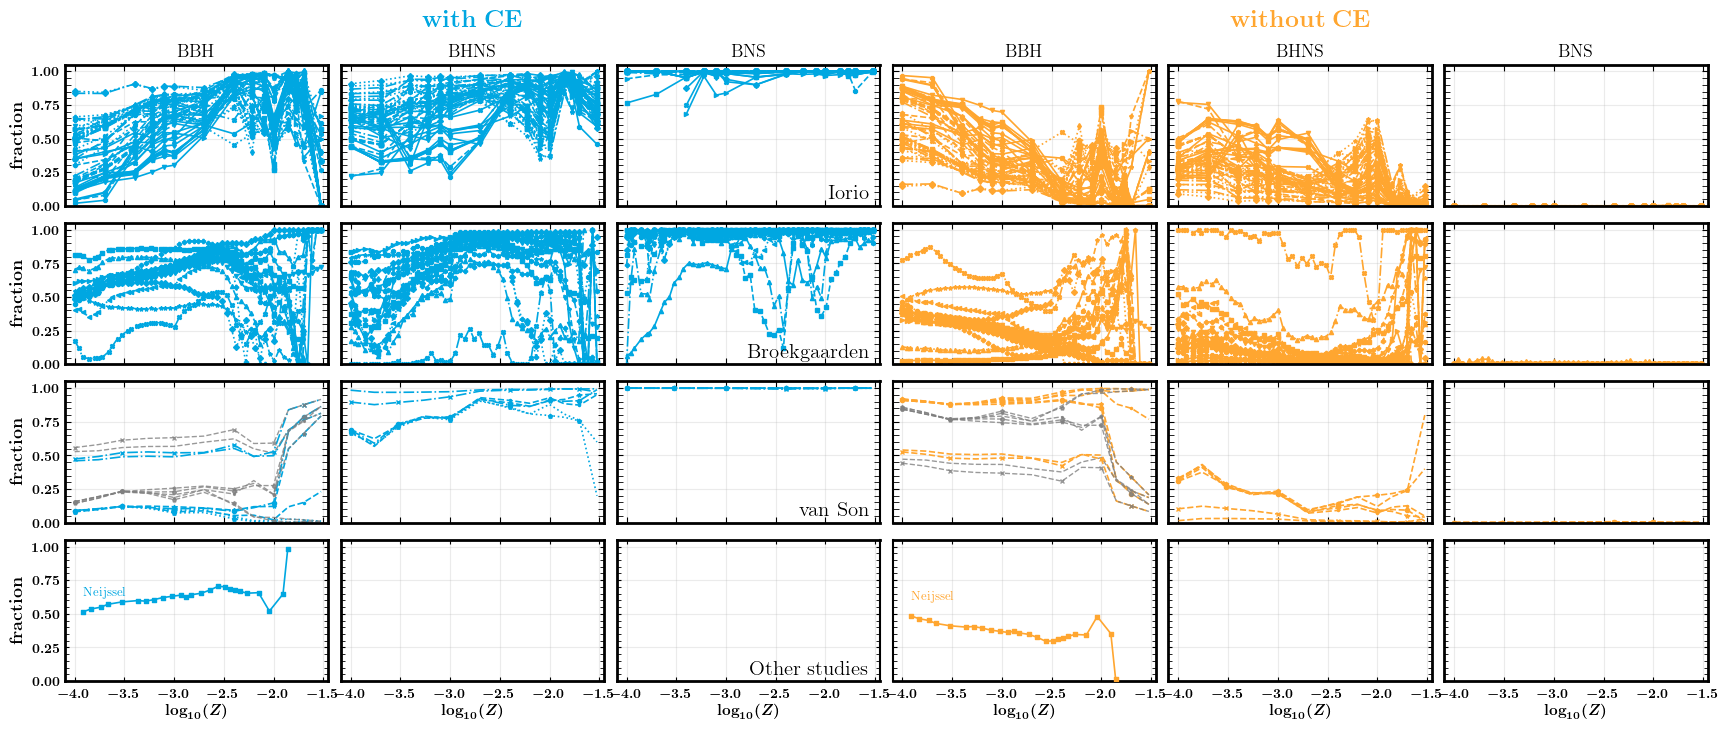

In [111]:
processed_digitized_csv = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/data_for_formation_efficiency/processed_channels.csv"

fig_combined, axes_combined = make_combined_ce_figure_3x6(
    iorio_model_dic=iorio_model_dic,
    broek_csvPath=broek_csvPath,
    sim_name_dict=sim_name_dict,
    yield_data=yield_data,
    processed_digitized_csv=processed_digitized_csv,
    include_vii_in_with_CE=False,
    broek_plot_fraction=True,
    broek_min_total_mask=0.0,
    broek_models_to_plot=broek_models_to_plot,
    figsize=(18, 8.2),
    savefile="combined_with_and_without_CE_4x6.pdf",
)




In [14]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================================================
# USER COLORS
# ============================================================
COLORS = {
    "orange_light": "#FFD08A",  # stable only for van Son BBH without-CE
    "orange_main":  "#FFA630",  # without CE
    "blue_main":    "#00A7E1",  # with CE
}

LABEL_SIZE = 11
TITLE_SIZE = 13

# ============================================================
# GLOBAL PLOT STYLE
# ============================================================
LINEWIDTH_MAIN = 1.2
LINEWIDTH_SECONDARY = 1.0   # for BBH stable-only van Son line

MARKERSIZE_MAIN = 3.0
MARKERSIZE_VANSON = 3.0
MARKERSIZE_SECONDARY = 2.6

ALPHA_MAIN = 1
ALPHA_SECONDARY = 0.8


# ============================================================
# IORIO PART
# ============================================================

def iorio_compute_collapsed_fractions(
    df,
    alpha,
    bco_type,
    min_with_ce_count_bns=1,
    min_total_count_bns=1,
    mask_zero_bns=True,
):
    """
    Return fractions as a function of Z:
      with_CE    = CI + CIII + CIV
      without_CE = CII
      others     = 1 - (with_CE + without_CE)
    """
    sub = df[df["alpha"] == alpha].sort_values("Z")
    if sub.empty:
        return None

    z = sub["Z"].to_numpy(dtype=float)
    tot = sub[bco_type].to_numpy(dtype=float)
    ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
    cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
    ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
    civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

    with_ce_count = ci + ciii + civ

    with np.errstate(divide="ignore", invalid="ignore"):
        f_i = np.divide(ci, tot, out=np.full_like(ci, np.nan), where=tot > 0)
        f_ii = np.divide(cii, tot, out=np.full_like(cii, np.nan), where=tot > 0)
        f_iii = np.divide(ciii, tot, out=np.full_like(ciii, np.nan), where=tot > 0)
        f_iv = np.divide(civ, tot, out=np.full_like(civ, np.nan), where=tot > 0)

    f_with_ce = f_i + f_iii + f_iv
    f_without_ce = f_ii
    f_others = 1.0 - (f_with_ce + f_without_ce)

    if bco_type in {"NSNS", "NSNSm"}:
        bad = np.zeros_like(z, dtype=bool)
        if min_with_ce_count_bns is not None:
            bad |= (with_ce_count < min_with_ce_count_bns)
        if min_total_count_bns is not None:
            bad |= (tot < min_total_count_bns)
        if mask_zero_bns:
            bad |= (with_ce_count <= 0)

        f_with_ce = f_with_ce.astype(float)
        f_with_ce[bad] = np.nan

    return {
        "Z": z,
        "logZ": np.log10(z),
        "with_CE": f_with_ce,
        "without_CE": f_without_ce,
        "others": f_others,
    }


def plot_iorio_panel(
    ax,
    model_dic,
    which_fraction="with_CE",
    bco_type="BHBHm",
):
    color = COLORS["blue_main"] if which_fraction == "with_CE" else COLORS["orange_main"]

    all_alphas = set()
    for _, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if os.path.exists(summary_file):
            df = pd.read_csv(summary_file)
            all_alphas.update(df["alpha"].dropna().unique())
    all_alphas = sorted(all_alphas)

    linestyle_cycle = ["-", "--", "-.", ":"]
    alpha_linestyles = {
        alpha: linestyle_cycle[i % len(linestyle_cycle)]
        for i, alpha in enumerate(all_alphas)
    }

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
    model_names = list(model_dic.keys())
    model_markers = {
        model: marker_cycle[i % len(marker_cycle)]
        for i, model in enumerate(model_names)
    }

    for model, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if not os.path.exists(summary_file):
            print(f"Warning: missing file {summary_file}")
            continue

        df = pd.read_csv(summary_file)
        alphas = sorted(df["alpha"].dropna().unique())

        for alpha in alphas:
            result = iorio_compute_collapsed_fractions(df, alpha, bco_type)
            if result is None:
                continue

            ax.plot(
                result["logZ"],
                result[which_fraction],
                color=color,
                linestyle=alpha_linestyles[alpha],
                marker=model_markers[model],
                ms=MARKERSIZE_MAIN,
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
            )

    ax.set_xlim(-4.1, -1.45)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


# ============================================================
# BROEKGAARDEN PART
# ============================================================

def load_grouped_formation_channels(
    df,
    bps_model,
    headerDict_Z_rev,
    include_vii_in_with_CE=False,
):
    ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

    with_CE = ch_classic + ch_immed + ch_double
    if include_vii_in_with_CE:
        with_CE = with_CE + ch_vii

    without_CE = ch_stable
    other = ch_other

    total = with_CE + without_CE + other
    if not include_vii_in_with_CE:
        total = total + ch_vii

    return {
        "with_CE": with_CE,
        "without_CE": without_CE,
        "other": other,
        "total": total,
        "vii": ch_vii,
    }


def get_grouped_fraction_or_yield(grouped, grouped_key="with_CE", plot_fraction=True):
    y = np.asarray(grouped[grouped_key], dtype=float)
    total = np.asarray(grouped["total"], dtype=float)

    if plot_fraction:
        yplot = np.divide(
            y,
            total,
            out=np.full_like(y, np.nan, dtype=float),
            where=(total > 0)
        )
    else:
        yplot = y * 1e5

    return yplot, total


def mask_low_total_points(yplot, total, min_total=0.0):
    ymasked = np.array(yplot, copy=True)
    ymasked[total <= min_total] = np.nan
    return ymasked


def plot_broekgaarden_panel(
    ax,
    csvPath,
    DCOtype="BBH",
    grouped_key="with_CE",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,
    models_to_plot=None,
):
    color = COLORS["blue_main"] if grouped_key == "with_CE" else COLORS["orange_main"]

    dictDCOtypeDCOlabel = {
        "BBH": "BHBH",
        "BHNS": "BHNS",
        "BNS": "NSNS",
    }

    if models_to_plot is None:
        models_to_plot = list(string.ascii_uppercase[:nModels])

    log10metallicities = np.log10(np.asarray(metallicities_list, dtype=float))

    csv_file = os.path.join(
        csvPath,
        f"formation_channels_per_Z_hdf5weights_{dictDCOtypeDCOlabel[DCOtype]}.csv"
    )
    df = pd.read_csv(csv_file, index_col=0)

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
    linestyle_cycle = ["-", "--", "-.", ":"]

    model_markers = {
        model: marker_cycle[i % len(marker_cycle)]
        for i, model in enumerate(models_to_plot)
    }
    model_linestyles = {
        model: linestyle_cycle[i % len(linestyle_cycle)]
        for i, model in enumerate(models_to_plot)
    }

    for bps_model in models_to_plot:
        grouped = load_grouped_formation_channels(
            df=df,
            bps_model=bps_model,
            headerDict_Z_rev=headerDict_Z_rev,
            include_vii_in_with_CE=include_vii_in_with_CE,
        )

        yplot, total = get_grouped_fraction_or_yield(
            grouped,
            grouped_key=grouped_key,
            plot_fraction=plot_fraction,
        )

        if min_total_mask is not None:
            yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

        ax.plot(
            log10metallicities,
            yplot,
            lw=LINEWIDTH_MAIN,
            linestyle=model_linestyles[bps_model],
            marker=model_markers[bps_model],
            ms=MARKERSIZE_MAIN,
            color=color,
            alpha=ALPHA_MAIN,
        )

    ax.set_xlim(-4.1, -1.45)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


# ============================================================
# VAN SON PART
# Requires:
# - sim_name_dict
# - yield_data
# - DCO_flavors = ['BBH', 'BHNS', 'NSNS']  (or compatible names)
# ============================================================

def vanson_get_fraction_arrays(data, flavor):
    """
    Returns fractional channel contributions for van Son data.

    For BBH:
      with_CE          = CE / (CE + stable + CHE)
      without_CE_main  = (stable + CHE) / (CE + stable + CHE)
      without_CE_light = stable / (CE + stable + CHE)

    For BHNS/BNS:
      with_CE          = CE / (CE + stable)
      without_CE_main  = stable / (CE + stable)
      without_CE_light = None
    """
    flav_data = data[flavor]

    ce_vals = np.asarray(flav_data["CE_group_lengths"], dtype=float)
    stable_vals = np.asarray(flav_data["stable_group_lengths"], dtype=float)

    if "CHEstable_group_lengths" in flav_data:
        che_vals = np.asarray(flav_data["CHEstable_group_lengths"], dtype=float)
    else:
        che_vals = np.zeros_like(ce_vals)

    is_bbh = (flavor == "BBH")

    if is_bbh:
        denom = ce_vals + stable_vals + che_vals
    else:
        denom = ce_vals + stable_vals

    with np.errstate(divide="ignore", invalid="ignore"):
        with_ce = np.divide(
            ce_vals, denom,
            out=np.full_like(ce_vals, np.nan, dtype=float),
            where=(denom > 0)
        )

        without_main_num = stable_vals + che_vals if is_bbh else stable_vals
        without_main = np.divide(
            without_main_num, denom,
            out=np.full_like(stable_vals, np.nan, dtype=float),
            where=(denom > 0)
        )

        if is_bbh:
            without_light = np.divide(
                stable_vals, denom,
                out=np.full_like(stable_vals, np.nan, dtype=float),
                where=(denom > 0)
            )
        else:
            without_light = None

    return {
        "with_CE": with_ce,
        "without_CE": without_main,          # stable+CHE for BBH, stable for BHNS/BNS
        "without_CE_stable_only": without_light,  # only for BBH
    }


def plot_vanson_panel(
    ax,
    which_fraction="with_CE",
    flavor="BBH",
    sim_name_dict=None,
    yield_data=None,
):
    """
    Plot one van Son panel.

    Special case:
    - For BBH + without_CE:
      plot stable only in light orange
      and stable+CHE in orange_main
    """
    zvals_set = False

    for sim_name, (Lab, _, lines, mark, LW) in sim_name_dict.items():
        data = yield_data[sim_name]
        zvals = np.log10(data["Z_values"] / 0.014) + np.log10(0.014)
        zvals_set = True

        fracs = vanson_get_fraction_arrays(data, flavor)

        if which_fraction == "with_CE":
            ax.plot(
                zvals,
                fracs["with_CE"],
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
                ls=lines,
                color=COLORS["blue_main"],
                marker=mark,
                markevery=2,
                markersize=MARKERSIZE_MAIN,
            )

        elif which_fraction == "without_CE":
            # Main without-CE line
            ax.plot(
                zvals,
                fracs["without_CE"],
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
                ls="--",
                color=COLORS["orange_main"],
                marker=mark,
                markevery=2,
                markersize=MARKERSIZE_MAIN,
            )

            # Extra conservative stable-only line for BBH
            if flavor == "BBH" and fracs["without_CE_stable_only"] is not None:
                ax.plot(
                    zvals,
                    fracs["without_CE_stable_only"],
                    lw=LINEWIDTH_SECONDARY,
                    alpha=ALPHA_SECONDARY,
                    ls="--",
                    color="gray",
                    marker=mark,
                    markevery=2,
                    markersize=MARKERSIZE_SECONDARY,
                )

    if zvals_set:
        ax.set_xlim(-4.1, -1.45)

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


# ============================================================
# COMBINED FIGURE: 3 ROWS
# ============================================================

def make_combined_ce_figure_3rows(
    iorio_model_dic,
    broek_csvPath,
    sim_name_dict,
    yield_data,
    which_fraction="with_CE",
    include_vii_in_with_CE=False,
    broek_plot_fraction=True,
    broek_min_total_mask=0.0,
    broek_models_to_plot=None,
    figsize=(10.5, 6.5),
    savefile=None,
):
    """
    Create a 3 x 3 figure:
      row 1 = Iorio
      row 2 = Broekgaarden
      row 3 = van Son

    cols = BBH, BHNS, BNS
    """
    if which_fraction not in {"with_CE", "without_CE"}:
        raise ValueError("which_fraction must be 'with_CE' or 'without_CE'")

    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    iorio_bco_order = [("BHBHm", "BBH"), ("BHNSm", "BHNS"), ("NSNSm", "BNS")]
    broek_dco_order = ["BBH", "BHNS", "BNS"]
    vanson_dco_order = ["BBH", "BHNS", "NSNS"]

    # -------------------------
    # Row 1: Iorio
    # -------------------------
    for j, (bco_type, label) in enumerate(iorio_bco_order):
        ax = axes[0, j]
        plot_iorio_panel(
            ax=ax,
            model_dic=iorio_model_dic,
            which_fraction=which_fraction,
            bco_type=bco_type,
        )

        ax.set_title(label, fontsize=TITLE_SIZE)
        if j == 0:
            ax.set_ylabel("fraction", fontsize=LABEL_SIZE)
        ax.tick_params(labelbottom=False)

    # -------------------------
    # Row 2: Broekgaarden
    # -------------------------
    for j, dco in enumerate(broek_dco_order):
        ax = axes[1, j]
        plot_broekgaarden_panel(
            ax=ax,
            csvPath=broek_csvPath,
            DCOtype=dco,
            grouped_key=which_fraction,
            include_vii_in_with_CE=include_vii_in_with_CE,
            plot_fraction=broek_plot_fraction,
            min_total_mask=broek_min_total_mask,
            models_to_plot=broek_models_to_plot,
        )

        if j == 0:
            ax.set_ylabel("fraction", fontsize=LABEL_SIZE)
        ax.tick_params(labelbottom=False)

    # -------------------------
    # Row 3: van Son
    # -------------------------
    for j, flavor in enumerate(vanson_dco_order):
        ax = axes[2, j]
        plot_vanson_panel(
            ax=ax,
            which_fraction=which_fraction,
            flavor=flavor,
            sim_name_dict=sim_name_dict,
            yield_data=yield_data,
        )

        if j == 0:
            ax.set_ylabel("fraction", fontsize=LABEL_SIZE)

        ax.set_xlabel(r"$\log_{10}(Z)$", fontsize=LABEL_SIZE)

    # Small row labels inside first column
    axes[0, 0].text(
        0.03, 0.95, "Iorio",
        transform=axes[0, 0].transAxes,
        ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )
    axes[1, 0].text(
        0.03, 0.95, "Broekgaarden",
        transform=axes[1, 0].transAxes,
        ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )
    axes[2, 0].text(
        0.03, 0.95, "van Son",
        transform=axes[2, 0].transAxes,
        ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )

    if which_fraction == "with_CE":
        title_text = "Formation-channel fraction with CE"
        title_color = COLORS["blue_main"]
    else:
        title_text = "Formation-channel fraction without CE"
        title_color = COLORS["orange_main"]

    fig.suptitle(title_text, fontsize=TITLE_SIZE + 2, y=0.92, color=title_color)
    fig.tight_layout(rect=[0.03, 0.03, 0.99, 0.96], w_pad=0.7, h_pad=0.7)

    if savefile is not None:
        fig.savefig(savefile, bbox_inches="tight", dpi=300)

    plt.show()
    return fig, axes


# ============================================================
# PATHS / INPUTS
# ============================================================

# ---------- Iorio ----------
iorio_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"
iorio_model_dic = {
    "F": os.path.join(iorio_loc, "simulation_F"),
    "QCBSE": os.path.join(iorio_loc, "simulation_QCBSE"),
    "QCBB": os.path.join(iorio_loc, "simulation_QCBB"),
    "RBSE": os.path.join(iorio_loc, "simulation_RBSE"),
    "NTC": os.path.join(iorio_loc, "simulation_NTC"),
    "NT": os.path.join(iorio_loc, "simulation_NT"),
    "QHE": os.path.join(iorio_loc, "simulation_QHE"),
    "F19": os.path.join(iorio_loc, "simulation_F19"),
    "K150": os.path.join(iorio_loc, "simulation_K150"),
    "K265": os.path.join(iorio_loc, "simulation_K265"),
    "LX": os.path.join(iorio_loc, "simulation_LX"),
    "LK": os.path.join(iorio_loc, "simulation_LK"),
    "LC": os.path.join(iorio_loc, "simulation_LC"),
    "SND": os.path.join(iorio_loc, "simulation_SND"),
    "OPT": os.path.join(iorio_loc, "simulation_OPT"),
    "F5M": os.path.join(iorio_loc, "simulation_F5M"),
}

# ---------- Broekgaarden ----------
broek_csvPath = "/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/"
broek_models_to_plot = None

# ---------- van Son ----------
# Uses your already-loaded:
# sim_name_dict
# yield_data


# ============================================================
# MAKE FIGURES
# ============================================================

fig_with, axes_with = make_combined_ce_figure_3rows(
    iorio_model_dic=iorio_model_dic,
    broek_csvPath=broek_csvPath,
    sim_name_dict=sim_name_dict,
    yield_data=yield_data,
    which_fraction="with_CE",
    include_vii_in_with_CE=False,
    broek_plot_fraction=True,
    broek_min_total_mask=0.0,
    broek_models_to_plot=broek_models_to_plot,
    figsize=(10.5, 6.5),
    savefile="combined_with_CE_3rows.pdf",
)

fig_without, axes_without = make_combined_ce_figure_3rows(
    iorio_model_dic=iorio_model_dic,
    broek_csvPath=broek_csvPath,
    sim_name_dict=sim_name_dict,
    yield_data=yield_data,
    which_fraction="without_CE",
    include_vii_in_with_CE=False,
    broek_plot_fraction=True,
    broek_min_total_mask=0.0,
    broek_models_to_plot=broek_models_to_plot,
    figsize=(10.5, 6.5),
    savefile="combined_without_CE_3rows.pdf",
)

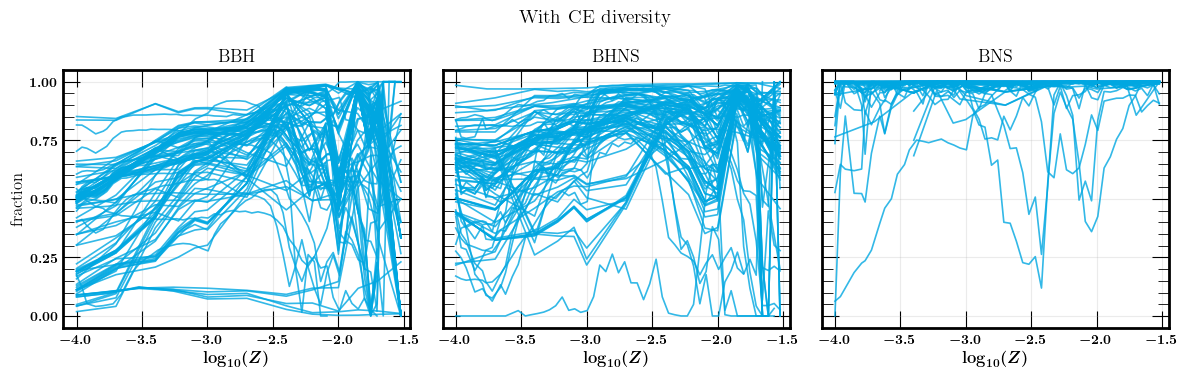

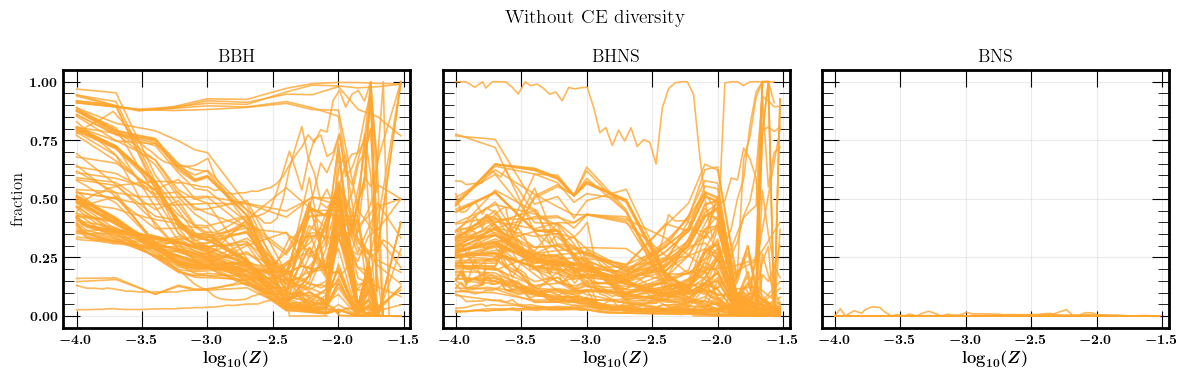

In [17]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================================================
# SIMPLE PLOT STYLE: no discrimination between studies/models
# ============================================================

COLORS = {
    "with_CE": "#00A7E1",
    "without_CE": "#FFA630",
}

LABEL_SIZE = 12
TITLE_SIZE = 13

LINEWIDTH = 1.2
ALPHA = 0.8
LINESTYLE = "-"
MARKER = None   # set to "o" if you still want points
MARKERSIZE = 2.5


# ============================================================
# IORIO
# ============================================================

def iorio_compute_collapsed_fractions(
    df,
    alpha,
    bco_type,
    min_with_ce_count_bns=1,
    min_total_count_bns=1,
    mask_zero_bns=True,
):
    sub = df[df["alpha"] == alpha].sort_values("Z")
    if sub.empty:
        return None

    z = sub["Z"].to_numpy(dtype=float)
    tot = sub[bco_type].to_numpy(dtype=float)
    ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
    cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
    ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
    civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

    with_ce_count = ci + ciii + civ

    with np.errstate(divide="ignore", invalid="ignore"):
        f_i = np.divide(ci, tot, out=np.full_like(ci, np.nan), where=tot > 0)
        f_ii = np.divide(cii, tot, out=np.full_like(cii, np.nan), where=tot > 0)
        f_iii = np.divide(ciii, tot, out=np.full_like(ciii, np.nan), where=tot > 0)
        f_iv = np.divide(civ, tot, out=np.full_like(civ, np.nan), where=tot > 0)

    f_with_ce = f_i + f_iii + f_iv
    f_without_ce = f_ii

    if bco_type in {"NSNS", "NSNSm"}:
        bad = np.zeros_like(z, dtype=bool)
        if min_with_ce_count_bns is not None:
            bad |= (with_ce_count < min_with_ce_count_bns)
        if min_total_count_bns is not None:
            bad |= (tot < min_total_count_bns)
        if mask_zero_bns:
            bad |= (with_ce_count <= 0)
        f_with_ce = f_with_ce.astype(float)
        f_with_ce[bad] = np.nan

    return {
        "logZ": np.log10(z),
        "with_CE": f_with_ce,
        "without_CE": f_without_ce,
    }


def plot_iorio_all_same_style(ax, model_dic, which_fraction="with_CE", bco_type="BHBHm"):
    color = COLORS[which_fraction]

    for _, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if not os.path.exists(summary_file):
            continue

        df = pd.read_csv(summary_file)
        alphas = sorted(df["alpha"].dropna().unique())

        for alpha in alphas:
            result = iorio_compute_collapsed_fractions(df, alpha, bco_type)
            if result is None:
                continue

            ax.plot(
                result["logZ"],
                result[which_fraction],
                color=color,
                lw=LINEWIDTH,
                alpha=ALPHA,
                ls=LINESTYLE,
                marker=MARKER,
                ms=MARKERSIZE,
            )


# ============================================================
# BROEKGAARDEN
# Requires:
# - nModels
# - metallicities_list
# - headerDict_Z_rev
# ============================================================

def load_grouped_formation_channels(
    df,
    bps_model,
    headerDict_Z_rev,
    include_vii_in_with_CE=False,
):
    ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

    with_CE = ch_classic + ch_immed + ch_double
    if include_vii_in_with_CE:
        with_CE = with_CE + ch_vii

    without_CE = ch_stable
    other = ch_other

    total = with_CE + without_CE + other
    if not include_vii_in_with_CE:
        total = total + ch_vii

    return {
        "with_CE": with_CE,
        "without_CE": without_CE,
        "other": other,
        "total": total,
    }


def get_grouped_fraction(grouped, grouped_key="with_CE"):
    y = np.asarray(grouped[grouped_key], dtype=float)
    total = np.asarray(grouped["total"], dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        yfrac = np.divide(y, total, out=np.full_like(y, np.nan), where=(total > 0))

    return yfrac, total


def mask_low_total_points(yplot, total, min_total=0.0):
    ymasked = np.array(yplot, copy=True)
    ymasked[total <= min_total] = np.nan
    return ymasked


def plot_broekgaarden_all_same_style(
    ax,
    csvPath,
    DCOtype="BBH",
    grouped_key="with_CE",
    include_vii_in_with_CE=False,
    min_total_mask=0.0,
    models_to_plot=None,
):
    color = COLORS[grouped_key]

    dictDCOtypeDCOlabel = {
        "BBH": "BHBH",
        "BHNS": "BHNS",
        "BNS": "NSNS",
    }

    if models_to_plot is None:
        models_to_plot = list(string.ascii_uppercase[:nModels])

    log10metallicities = np.log10(np.asarray(metallicities_list, dtype=float))

    csv_file = os.path.join(
        csvPath,
        f"formation_channels_per_Z_hdf5weights_{dictDCOtypeDCOlabel[DCOtype]}.csv"
    )
    df = pd.read_csv(csv_file, index_col=0)

    for bps_model in models_to_plot:
        grouped = load_grouped_formation_channels(
            df=df,
            bps_model=bps_model,
            headerDict_Z_rev=headerDict_Z_rev,
            include_vii_in_with_CE=include_vii_in_with_CE,
        )

        yplot, total = get_grouped_fraction(grouped, grouped_key=grouped_key)

        if min_total_mask is not None:
            yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

        ax.plot(
            log10metallicities,
            yplot,
            color=color,
            lw=LINEWIDTH,
            alpha=ALPHA,
            ls=LINESTYLE,
            marker=MARKER,
            ms=MARKERSIZE,
        )


# ============================================================
# VAN SON
# Requires:
# - sim_name_dict
# - yield_data
# ============================================================

def vanson_get_fraction_arrays(data, flavor):
    flav_data = data[flavor]

    ce_vals = np.asarray(flav_data["CE_group_lengths"], dtype=float)
    stable_vals = np.asarray(flav_data["stable_group_lengths"], dtype=float)

    if "CHEstable_group_lengths" in flav_data:
        che_vals = np.asarray(flav_data["CHEstable_group_lengths"], dtype=float)
    else:
        che_vals = np.zeros_like(ce_vals)

    is_bbh = (flavor == "BBH")

    if is_bbh:
        denom = ce_vals + stable_vals + che_vals
    else:
        denom = ce_vals + stable_vals

    with np.errstate(divide="ignore", invalid="ignore"):
        with_ce = np.divide(ce_vals, denom, out=np.full_like(ce_vals, np.nan), where=(denom > 0))
        without_ce = np.divide(
            stable_vals + che_vals if is_bbh else stable_vals,
            denom,
            out=np.full_like(stable_vals, np.nan),
            where=(denom > 0)
        )

    return {
        "with_CE": with_ce,
        "without_CE": without_ce,
    }


def plot_vanson_all_same_style(ax, which_fraction="with_CE", flavor="BBH", sim_name_dict=None, yield_data=None):
    color = COLORS[which_fraction]

    for sim_name in sim_name_dict.keys():
        data = yield_data[sim_name]
        zvals = np.log10(data["Z_values"] / 0.014) + np.log10(0.014)
        fracs = vanson_get_fraction_arrays(data, flavor)

        ax.plot(
            zvals,
            fracs[which_fraction],
            color=color,
            lw=LINEWIDTH,
            alpha=ALPHA,
            ls=LINESTYLE,
            marker=MARKER,
            ms=MARKERSIZE,
        )


# ============================================================
# PANEL FORMATTING
# ============================================================

def format_fraction_panel(ax, title=None):
    ax.set_xlim(-4.1, -1.45)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    if title is not None:
        ax.set_title(title, fontsize=TITLE_SIZE)


# ============================================================
# MAIN FIGURE
# ============================================================

def make_diversity_figure(
    iorio_model_dic,
    broek_csvPath,
    sim_name_dict,
    yield_data,
    which_fraction="with_CE",
    include_vii_in_with_CE=False,
    broek_min_total_mask=0.0,
    broek_models_to_plot=None,
    figsize=(12, 3.8),
    savefile=None,
):
    """
    One figure with 3 panels:
      BBH | BHNS | BNS

    Every curve from every study is plotted in the same visual style.
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)

    # Mapping between each framework and panel label
    panel_info = [
        ("BBH",  "BHBHm",  "BBH",  "BBH"),
        ("BHNS", "BHNSm",  "BHNS", "BHNS"),
        ("BNS",  "NSNSm",  "BNS",  "NSNS"),
    ]

    for ax, (label, iorio_type, broek_type, vanson_type) in zip(axes, panel_info):
        # Iorio
        plot_iorio_all_same_style(
            ax=ax,
            model_dic=iorio_model_dic,
            which_fraction=which_fraction,
            bco_type=iorio_type,
        )

        # Broekgaarden
        plot_broekgaarden_all_same_style(
            ax=ax,
            csvPath=broek_csvPath,
            DCOtype=broek_type,
            grouped_key=which_fraction,
            include_vii_in_with_CE=include_vii_in_with_CE,
            min_total_mask=broek_min_total_mask,
            models_to_plot=broek_models_to_plot,
        )

        # van Son
        plot_vanson_all_same_style(
            ax=ax,
            which_fraction=which_fraction,
            flavor=vanson_type,
            sim_name_dict=sim_name_dict,
            yield_data=yield_data,
        )

        format_fraction_panel(ax, title=label)
        ax.set_xlabel(r"$\log_{10}(Z)$", fontsize=LABEL_SIZE)

    axes[0].set_ylabel("fraction", fontsize=LABEL_SIZE)

    title_text = "With CE diversity" if which_fraction == "with_CE" else "Without CE diversity"
    fig.suptitle(title_text, fontsize=TITLE_SIZE + 1, y=0.98)
    fig.tight_layout()

    if savefile is not None:
        fig.savefig(savefile, bbox_inches="tight", dpi=300)

    plt.show()
    return fig, axes




# ============================================================
# MAKE THE TWO FIGURES
# ============================================================

fig_with, axes_with = make_diversity_figure(
    iorio_model_dic=iorio_model_dic,
    broek_csvPath=broek_csvPath,
    sim_name_dict=sim_name_dict,
    yield_data=yield_data,
    which_fraction="with_CE",
    include_vii_in_with_CE=False,
    broek_min_total_mask=0.0,
    broek_models_to_plot=broek_models_to_plot,
    figsize=(12, 3.8),
    savefile="allstudies_with_CE_diversity.pdf",
)

fig_without, axes_without = make_diversity_figure(
    iorio_model_dic=iorio_model_dic,
    broek_csvPath=broek_csvPath,
    sim_name_dict=sim_name_dict,
    yield_data=yield_data,
    which_fraction="without_CE",
    include_vii_in_with_CE=False,
    broek_min_total_mask=0.0,
    broek_models_to_plot=broek_models_to_plot,
    figsize=(12, 3.8),
    savefile="allstudies_without_CE_diversity.pdf",
)




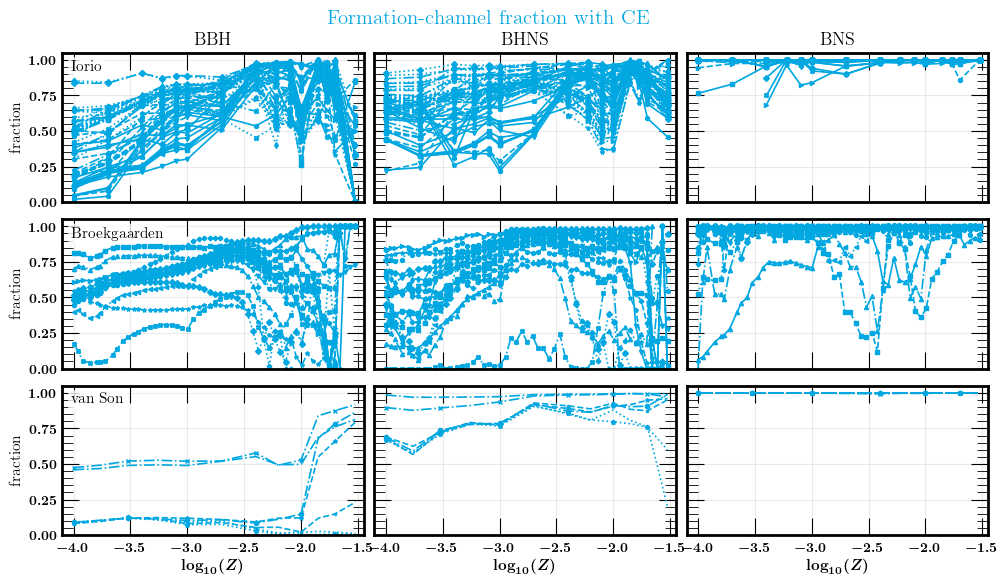

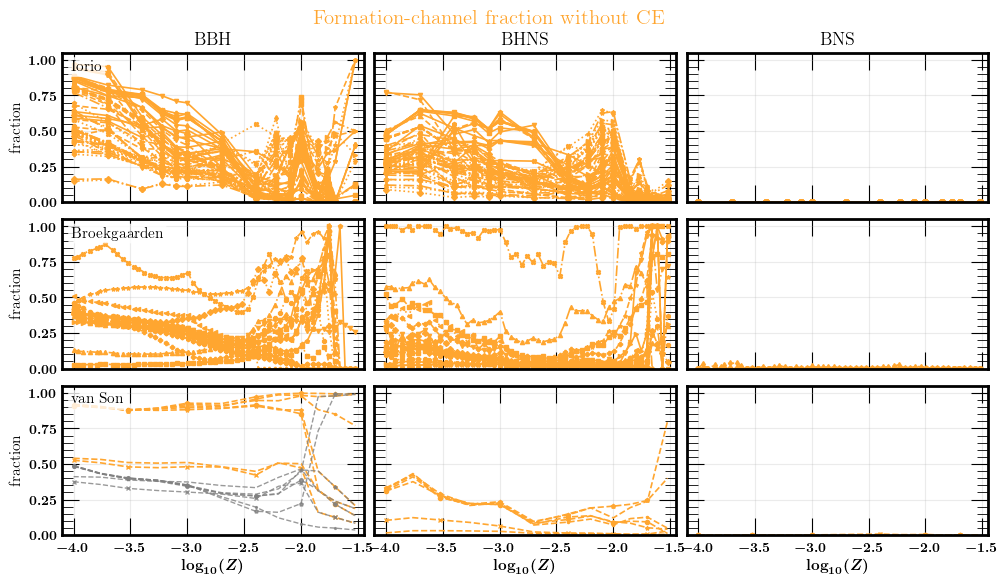

In [24]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================================================
# USER COLORS
# ============================================================
COLORS = {
    "orange_light": "#FFD08A",  # stable only for van Son BBH without-CE
    "orange_main":  "#FFA630",  # without CE
    "blue_main":    "#00A7E1",  # with CE
}

LABEL_SIZE = 11
TITLE_SIZE = 13

# ============================================================
# GLOBAL PLOT STYLE
# ============================================================
LINEWIDTH_MAIN = 1.2
LINEWIDTH_SECONDARY = 1.0   # for BBH stable-only van Son line

MARKERSIZE_MAIN = 3.0
MARKERSIZE_VANSON = 3.0
MARKERSIZE_SECONDARY = 2.6

ALPHA_MAIN = 1
ALPHA_SECONDARY = 0.8


# ============================================================
# IORIO PART
# ============================================================

def iorio_compute_collapsed_fractions(
    df,
    alpha,
    bco_type,
    min_with_ce_count_bns=1,
    min_total_count_bns=1,
    mask_zero_bns=True,
):
    """
    Return fractions as a function of Z:
      with_CE    = CI + CIII + CIV
      without_CE = CII
      others     = 1 - (with_CE + without_CE)
    """
    sub = df[df["alpha"] == alpha].sort_values("Z")
    if sub.empty:
        return None

    z = sub["Z"].to_numpy(dtype=float)
    tot = sub[bco_type].to_numpy(dtype=float)
    ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
    cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
    ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
    civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

    with_ce_count = ci + ciii + civ

    with np.errstate(divide="ignore", invalid="ignore"):
        f_i = np.divide(ci, tot, out=np.full_like(ci, np.nan), where=tot > 0)
        f_ii = np.divide(cii, tot, out=np.full_like(cii, np.nan), where=tot > 0)
        f_iii = np.divide(ciii, tot, out=np.full_like(ciii, np.nan), where=tot > 0)
        f_iv = np.divide(civ, tot, out=np.full_like(civ, np.nan), where=tot > 0)

    f_with_ce = f_i + f_iii + f_iv
    f_without_ce = f_ii
    f_others = 1.0 - (f_with_ce + f_without_ce)

    if bco_type in {"NSNS", "NSNSm"}:
        bad = np.zeros_like(z, dtype=bool)
        if min_with_ce_count_bns is not None:
            bad |= (with_ce_count < min_with_ce_count_bns)
        if min_total_count_bns is not None:
            bad |= (tot < min_total_count_bns)
        if mask_zero_bns:
            bad |= (with_ce_count <= 0)

        f_with_ce = f_with_ce.astype(float)
        f_with_ce[bad] = np.nan

    return {
        "Z": z,
        "logZ": np.log10(z),
        "with_CE": f_with_ce,
        "without_CE": f_without_ce,
        "others": f_others,
    }


def plot_iorio_panel(
    ax,
    model_dic,
    which_fraction="with_CE",
    bco_type="BHBHm",
):
    color = COLORS["blue_main"] if which_fraction == "with_CE" else COLORS["orange_main"]

    all_alphas = set()
    for _, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if os.path.exists(summary_file):
            df = pd.read_csv(summary_file)
            all_alphas.update(df["alpha"].dropna().unique())
    all_alphas = sorted(all_alphas)

    linestyle_cycle = ["-", "--", "-.", ":"]
    alpha_linestyles = {
        alpha: linestyle_cycle[i % len(linestyle_cycle)]
        for i, alpha in enumerate(all_alphas)
    }

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
    model_names = list(model_dic.keys())
    model_markers = {
        model: marker_cycle[i % len(marker_cycle)]
        for i, model in enumerate(model_names)
    }

    for model, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if not os.path.exists(summary_file):
            print(f"Warning: missing file {summary_file}")
            continue

        df = pd.read_csv(summary_file)
        alphas = sorted(df["alpha"].dropna().unique())

        for alpha in alphas:
            result = iorio_compute_collapsed_fractions(df, alpha, bco_type)
            if result is None:
                continue

            ax.plot(
                result["logZ"],
                result[which_fraction],
                color=color,
                linestyle=alpha_linestyles[alpha],
                marker=model_markers[model],
                ms=MARKERSIZE_MAIN,
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
            )

    ax.set_xlim(-4.1, -1.45)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


# ============================================================
# BROEKGAARDEN PART
# ============================================================

def load_grouped_formation_channels(
    df,
    bps_model,
    headerDict_Z_rev,
    include_vii_in_with_CE=False,
):
    ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

    with_CE = ch_classic + ch_immed + ch_double
    if include_vii_in_with_CE:
        with_CE = with_CE + ch_vii

    without_CE = ch_stable
    other = ch_other

    total = with_CE + without_CE + other
    if not include_vii_in_with_CE:
        total = total + ch_vii

    return {
        "with_CE": with_CE,
        "without_CE": without_CE,
        "other": other,
        "total": total,
        "vii": ch_vii,
    }


def get_grouped_fraction_or_yield(grouped, grouped_key="with_CE", plot_fraction=True):
    y = np.asarray(grouped[grouped_key], dtype=float)
    total = np.asarray(grouped["total"], dtype=float)

    if plot_fraction:
        yplot = np.divide(
            y,
            total,
            out=np.full_like(y, np.nan, dtype=float),
            where=(total > 0)
        )
    else:
        yplot = y * 1e5

    return yplot, total


def mask_low_total_points(yplot, total, min_total=0.0):
    ymasked = np.array(yplot, copy=True)
    ymasked[total <= min_total] = np.nan
    return ymasked


def plot_broekgaarden_panel(
    ax,
    csvPath,
    DCOtype="BBH",
    grouped_key="with_CE",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,
    models_to_plot=None,
):
    color = COLORS["blue_main"] if grouped_key == "with_CE" else COLORS["orange_main"]

    dictDCOtypeDCOlabel = {
        "BBH": "BHBH",
        "BHNS": "BHNS",
        "BNS": "NSNS",
    }

    if models_to_plot is None:
        models_to_plot = list(string.ascii_uppercase[:nModels])

    log10metallicities = np.log10(np.asarray(metallicities_list, dtype=float))

    csv_file = os.path.join(
        csvPath,
        f"formation_channels_per_Z_hdf5weights_{dictDCOtypeDCOlabel[DCOtype]}.csv"
    )
    df = pd.read_csv(csv_file, index_col=0)

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
    linestyle_cycle = ["-", "--", "-.", ":"]

    model_markers = {
        model: marker_cycle[i % len(marker_cycle)]
        for i, model in enumerate(models_to_plot)
    }
    model_linestyles = {
        model: linestyle_cycle[i % len(linestyle_cycle)]
        for i, model in enumerate(models_to_plot)
    }

    for bps_model in models_to_plot:
        grouped = load_grouped_formation_channels(
            df=df,
            bps_model=bps_model,
            headerDict_Z_rev=headerDict_Z_rev,
            include_vii_in_with_CE=include_vii_in_with_CE,
        )

        yplot, total = get_grouped_fraction_or_yield(
            grouped,
            grouped_key=grouped_key,
            plot_fraction=plot_fraction,
        )

        if min_total_mask is not None:
            yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

        ax.plot(
            log10metallicities,
            yplot,
            lw=LINEWIDTH_MAIN,
            linestyle=model_linestyles[bps_model],
            marker=model_markers[bps_model],
            ms=MARKERSIZE_MAIN,
            color=color,
            alpha=ALPHA_MAIN,
        )

    ax.set_xlim(-4.1, -1.45)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


# ============================================================
# VAN SON PART
# Requires:
# - sim_name_dict
# - yield_data
# - DCO_flavors = ['BBH', 'BHNS', 'NSNS']  (or compatible names)
# ============================================================

def vanson_get_fraction_arrays(data, flavor):
    """
    Returns fractional channel contributions for van Son data.

    For BBH:
      with_CE          = CE / (CE + stable + CHE)
      without_CE_main  = (stable + CHE) / (CE + stable + CHE)
      without_CE_light = stable / (CE + stable + CHE)

    For BHNS/BNS:
      with_CE          = CE / (CE + stable)
      without_CE_main  = stable / (CE + stable)
      without_CE_light = None
    """
    flav_data = data[flavor]

    ce_vals = np.asarray(flav_data["CE_group_lengths"], dtype=float)
    stable_vals = np.asarray(flav_data["stable_group_lengths"], dtype=float)

    if "CHEstable_group_lengths" in flav_data:
        che_vals = np.asarray(flav_data["CHEstable_group_lengths"], dtype=float)
    else:
        che_vals = np.zeros_like(ce_vals)

    is_bbh = (flavor == "BBH")

    if is_bbh:
        denom = ce_vals + stable_vals + che_vals
    else:
        denom = ce_vals + stable_vals

    with np.errstate(divide="ignore", invalid="ignore"):
        with_ce = np.divide(
            ce_vals, denom,
            out=np.full_like(ce_vals, np.nan, dtype=float),
            where=(denom > 0)
        )

        without_main_num = stable_vals + che_vals if is_bbh else stable_vals
        without_main = np.divide(
            without_main_num, denom,
            out=np.full_like(stable_vals, np.nan, dtype=float),
            where=(denom > 0)
        )

        if is_bbh:
            without_light = np.divide(
                stable_vals, denom,
                out=np.full_like(stable_vals, np.nan, dtype=float),
                where=(denom > 0)
            )
        else:
            without_light = None

    return {
        "with_CE": with_ce,
        "without_CE": without_main,          # stable+CHE for BBH, stable for BHNS/BNS
        "without_CE_stable_only": without_light,  # only for BBH
    }


def plot_vanson_panel(
    ax,
    which_fraction="with_CE",
    flavor="BBH",
    sim_name_dict=None,
    yield_data=None,
):
    """
    Plot one van Son panel.

    Special case:
    - For BBH + without_CE:
      plot stable only in light orange
      and stable+CHE in orange_main
    """
    zvals_set = False

    for sim_name, (Lab, _, lines, mark, LW) in sim_name_dict.items():
        data = yield_data[sim_name]
        zvals = np.log10(data["Z_values"] / 0.014) + np.log10(0.014)
        zvals_set = True

        fracs = vanson_get_fraction_arrays(data, flavor)

        if which_fraction == "with_CE":
            ax.plot(
                zvals,
                fracs["with_CE"],
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
                ls=lines,
                color=COLORS["blue_main"],
                marker=mark,
                markevery=2,
                markersize=MARKERSIZE_MAIN,
            )

        elif which_fraction == "without_CE":
            # Main without-CE line
            ax.plot(
                zvals,
                fracs["without_CE"],
                lw=LINEWIDTH_MAIN,
                alpha=ALPHA_MAIN,
                ls="--",
                color=COLORS["orange_main"],
                marker=mark,
                markevery=2,
                markersize=MARKERSIZE_MAIN,
            )

            # Extra conservative stable-only line for BBH
            if flavor == "BBH" and fracs["without_CE_stable_only"] is not None:
                ax.plot(
                    zvals,
                    fracs["without_CE_stable_only"],
                    lw=LINEWIDTH_SECONDARY,
                    alpha=ALPHA_SECONDARY,
                    ls="--",
                    color="gray",
                    marker=mark,
                    markevery=2,
                    markersize=MARKERSIZE_SECONDARY,
                )

    if zvals_set:
        ax.set_xlim(-4.1, -1.45)

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


# ============================================================
# COMBINED FIGURE: 3 ROWS
# ============================================================

def make_combined_ce_figure_3rows(
    iorio_model_dic,
    broek_csvPath,
    sim_name_dict,
    yield_data,
    which_fraction="with_CE",
    include_vii_in_with_CE=False,
    broek_plot_fraction=True,
    broek_min_total_mask=0.0,
    broek_models_to_plot=None,
    figsize=(10.5, 6.5),
    savefile=None,
):
    """
    Create a 3 x 3 figure:
      row 1 = Iorio
      row 2 = Broekgaarden
      row 3 = van Son

    cols = BBH, BHNS, BNS
    """
    if which_fraction not in {"with_CE", "without_CE"}:
        raise ValueError("which_fraction must be 'with_CE' or 'without_CE'")

    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    iorio_bco_order = [("BHBHm", "BBH"), ("BHNSm", "BHNS"), ("NSNSm", "BNS")]
    broek_dco_order = ["BBH", "BHNS", "BNS"]
    vanson_dco_order = ["BBH", "BHNS", "NSNS"]

    # -------------------------
    # Row 1: Iorio
    # -------------------------
    for j, (bco_type, label) in enumerate(iorio_bco_order):
        ax = axes[0, j]
        plot_iorio_panel(
            ax=ax,
            model_dic=iorio_model_dic,
            which_fraction=which_fraction,
            bco_type=bco_type,
        )

        ax.set_title(label, fontsize=TITLE_SIZE)
        if j == 0:
            ax.set_ylabel("fraction", fontsize=LABEL_SIZE)
        ax.tick_params(labelbottom=False)

    # -------------------------
    # Row 2: Broekgaarden
    # -------------------------
    for j, dco in enumerate(broek_dco_order):
        ax = axes[1, j]
        plot_broekgaarden_panel(
            ax=ax,
            csvPath=broek_csvPath,
            DCOtype=dco,
            grouped_key=which_fraction,
            include_vii_in_with_CE=include_vii_in_with_CE,
            plot_fraction=broek_plot_fraction,
            min_total_mask=broek_min_total_mask,
            models_to_plot=broek_models_to_plot,
        )

        if j == 0:
            ax.set_ylabel("fraction", fontsize=LABEL_SIZE)
        ax.tick_params(labelbottom=False)

    # -------------------------
    # Row 3: van Son
    # -------------------------
    for j, flavor in enumerate(vanson_dco_order):
        ax = axes[2, j]
        plot_vanson_panel(
            ax=ax,
            which_fraction=which_fraction,
            flavor=flavor,
            sim_name_dict=sim_name_dict,
            yield_data=yield_data,
        )

        if j == 0:
            ax.set_ylabel("fraction", fontsize=LABEL_SIZE)

        ax.set_xlabel(r"$\log_{10}(Z)$", fontsize=LABEL_SIZE)

    # Small row labels inside first column
    axes[0, 0].text(
        0.03, 0.95, "Iorio",
        transform=axes[0, 0].transAxes,
        ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )
    axes[1, 0].text(
        0.03, 0.95, "Broekgaarden",
        transform=axes[1, 0].transAxes,
        ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )
    axes[2, 0].text(
        0.03, 0.95, "van Son",
        transform=axes[2, 0].transAxes,
        ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )

    if which_fraction == "with_CE":
        title_text = "Formation-channel fraction with CE"
        title_color = COLORS["blue_main"]
    else:
        title_text = "Formation-channel fraction without CE"
        title_color = COLORS["orange_main"]

    fig.suptitle(title_text, fontsize=TITLE_SIZE + 2, y=0.92, color=title_color)
    fig.tight_layout(rect=[0.03, 0.03, 0.99, 0.96], w_pad=0.7, h_pad=0.7)

    if savefile is not None:
        fig.savefig(savefile, bbox_inches="tight", dpi=300)

    plt.show()
    return fig, axes


# ============================================================
# PATHS / INPUTS
# ============================================================

# ---------- Iorio ----------
iorio_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"
iorio_model_dic = {
    "F": os.path.join(iorio_loc, "simulation_F"),
    "QCBSE": os.path.join(iorio_loc, "simulation_QCBSE"),
    "QCBB": os.path.join(iorio_loc, "simulation_QCBB"),
    "RBSE": os.path.join(iorio_loc, "simulation_RBSE"),
    "NTC": os.path.join(iorio_loc, "simulation_NTC"),
    "NT": os.path.join(iorio_loc, "simulation_NT"),
    "QHE": os.path.join(iorio_loc, "simulation_QHE"),
    "F19": os.path.join(iorio_loc, "simulation_F19"),
    "K150": os.path.join(iorio_loc, "simulation_K150"),
    "K265": os.path.join(iorio_loc, "simulation_K265"),
    "LX": os.path.join(iorio_loc, "simulation_LX"),
    "LK": os.path.join(iorio_loc, "simulation_LK"),
    "LC": os.path.join(iorio_loc, "simulation_LC"),
    "SND": os.path.join(iorio_loc, "simulation_SND"),
    "OPT": os.path.join(iorio_loc, "simulation_OPT"),
    "F5M": os.path.join(iorio_loc, "simulation_F5M"),
}

# ---------- Broekgaarden ----------
broek_csvPath = "/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/"
broek_models_to_plot = None

# ---------- van Son ----------
# Uses your already-loaded:
# sim_name_dict
# yield_data


# ============================================================
# MAKE FIGURES
# ============================================================

fig_with, axes_with = make_combined_ce_figure_3rows(
    iorio_model_dic=iorio_model_dic,
    broek_csvPath=broek_csvPath,
    sim_name_dict=sim_name_dict,
    yield_data=yield_data,
    which_fraction="with_CE",
    include_vii_in_with_CE=False,
    broek_plot_fraction=True,
    broek_min_total_mask=0.0,
    broek_models_to_plot=broek_models_to_plot,
    figsize=(10.5, 6.5),
    savefile="combined_with_CE_3rows.pdf",
)

fig_without, axes_without = make_combined_ce_figure_3rows(
    iorio_model_dic=iorio_model_dic,
    broek_csvPath=broek_csvPath,
    sim_name_dict=sim_name_dict,
    yield_data=yield_data,
    which_fraction="without_CE",
    include_vii_in_with_CE=False,
    broek_plot_fraction=True,
    broek_min_total_mask=0.0,
    broek_models_to_plot=broek_models_to_plot,
    figsize=(10.5, 6.5),
    savefile="combined_without_CE_3rows.pdf",
)

In [25]:
# import os
# import string
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator

# # ============================================================
# # USER COLORS
# # ============================================================
# COLORS = {
#     "orange_main": "#FFA630",   # without CE
#     "blue_main":   "#00A7E1",   # with CE
# }

# LABEL_SIZE = 11
# TITLE_SIZE = 13

# # ============================================================
# # IORIO PART
# # ============================================================

# def iorio_compute_collapsed_fractions(
#     df,
#     alpha,
#     bco_type,
#     min_with_ce_count_bns=1,
#     min_total_count_bns=1,
#     mask_zero_bns=True,
# ):
#     """
#     Return fractions as a function of Z:
#       with_CE    = CI + CIII + CIV
#       without_CE = CII
#       others     = 1 - (with_CE + without_CE)
#     """
#     sub = df[df["alpha"] == alpha].sort_values("Z")
#     if sub.empty:
#         return None

#     z = sub["Z"].to_numpy(dtype=float)
#     tot = sub[bco_type].to_numpy(dtype=float)
#     ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
#     cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
#     ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
#     civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

#     with_ce_count = ci + ciii + civ

#     with np.errstate(divide="ignore", invalid="ignore"):
#         f_i = np.divide(ci, tot, out=np.full_like(ci, np.nan), where=tot > 0)
#         f_ii = np.divide(cii, tot, out=np.full_like(cii, np.nan), where=tot > 0)
#         f_iii = np.divide(ciii, tot, out=np.full_like(ciii, np.nan), where=tot > 0)
#         f_iv = np.divide(civ, tot, out=np.full_like(civ, np.nan), where=tot > 0)

#     f_with_ce = f_i + f_iii + f_iv
#     f_without_ce = f_ii
#     f_others = 1.0 - (f_with_ce + f_without_ce)

#     # Optional masking for BNS with-CE
#     if bco_type in {"NSNS", "NSNSm"}:
#         bad = np.zeros_like(z, dtype=bool)

#         if min_with_ce_count_bns is not None:
#             bad |= (with_ce_count < min_with_ce_count_bns)
#         if min_total_count_bns is not None:
#             bad |= (tot < min_total_count_bns)
#         if mask_zero_bns:
#             bad |= (with_ce_count <= 0)

#         f_with_ce = f_with_ce.astype(float)
#         f_with_ce[bad] = np.nan

#     return {
#         "Z": z,
#         "logZ": np.log10(z),
#         "with_CE": f_with_ce,
#         "without_CE": f_without_ce,
#         "others": f_others,
#     }


# def plot_iorio_panel(
#     ax,
#     model_dic,
#     which_fraction="with_CE",
#     bco_type="BHBHm",
# ):
#     """
#     Plot one Iorio panel onto ax using log10(Z) on the x-axis.
#     """
#     color = COLORS["blue_main"] if which_fraction == "with_CE" else COLORS["orange_main"]

#     # collect all alpha values across all models
#     all_alphas = set()
#     for _, path in model_dic.items():
#         summary_file = os.path.join(path, "summary.csv")
#         if os.path.exists(summary_file):
#             df = pd.read_csv(summary_file)
#             all_alphas.update(df["alpha"].dropna().unique())
#     all_alphas = sorted(all_alphas)

#     linestyle_cycle = ["-", "--", "-.", ":"]
#     alpha_linestyles = {
#         alpha: linestyle_cycle[i % len(linestyle_cycle)]
#         for i, alpha in enumerate(all_alphas)
#     }

#     marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
#     model_names = list(model_dic.keys())
#     model_markers = {
#         model: marker_cycle[i % len(marker_cycle)]
#         for i, model in enumerate(model_names)
#     }

#     for model, path in model_dic.items():
#         summary_file = os.path.join(path, "summary.csv")
#         if not os.path.exists(summary_file):
#             print(f"Warning: missing file {summary_file}")
#             continue

#         df = pd.read_csv(summary_file)
#         alphas = sorted(df["alpha"].dropna().unique())

#         for alpha in alphas:
#             result = iorio_compute_collapsed_fractions(df, alpha, bco_type)
#             if result is None:
#                 continue

#             ax.plot(
#                 result["logZ"],
#                 result[which_fraction],
#                 color=color,
#                 linestyle=alpha_linestyles[alpha],
#                 marker=model_markers[model],
#                 ms=3.0,
#                 lw=1.2,
#                 alpha=0.8,
#             )

#     ax.set_xlim(-4.1, -1.45)
#     ax.set_ylim(0, 1.05)
#     ax.yaxis.set_major_locator(MultipleLocator(0.25))
#     ax.yaxis.set_minor_locator(MultipleLocator(0.05))
#     ax.grid(True, alpha=0.25)
#     ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


# # ============================================================
# # BROEKGAARDEN PART
# # ============================================================

# def load_grouped_formation_channels(
#     df,
#     bps_model,
#     headerDict_Z_rev,
#     include_vii_in_with_CE=False,
# ):
#     ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

#     with_CE = ch_classic + ch_immed + ch_double
#     if include_vii_in_with_CE:
#         with_CE = with_CE + ch_vii

#     without_CE = ch_stable
#     other = ch_other

#     total = with_CE + without_CE + other
#     if not include_vii_in_with_CE:
#         total = total + ch_vii

#     return {
#         "with_CE": with_CE,
#         "without_CE": without_CE,
#         "other": other,
#         "total": total,
#         "vii": ch_vii,
#     }


# def get_grouped_fraction_or_yield(grouped, grouped_key="with_CE", plot_fraction=True):
#     y = np.asarray(grouped[grouped_key], dtype=float)
#     total = np.asarray(grouped["total"], dtype=float)

#     if plot_fraction:
#         yplot = np.divide(
#             y,
#             total,
#             out=np.full_like(y, np.nan, dtype=float),
#             where=(total > 0)
#         )
#     else:
#         yplot = y * 1e5

#     return yplot, total


# def mask_low_total_points(yplot, total, min_total=0.0):
#     ymasked = np.array(yplot, copy=True)
#     ymasked[total <= min_total] = np.nan
#     return ymasked


# def plot_broekgaarden_panel(
#     ax,
#     csvPath,
#     DCOtype="BBH",
#     grouped_key="with_CE",
#     include_vii_in_with_CE=False,
#     plot_fraction=True,
#     min_total_mask=0.0,
#     models_to_plot=None,
# ):
#     """
#     Plot one Broekgaarden panel onto ax using log10(Z) on the x-axis.
#     """
#     color = COLORS["blue_main"] if grouped_key == "with_CE" else COLORS["orange_main"]

#     dictDCOtypeDCOlabel = {
#         "BBH": "BHBH",
#         "BHNS": "BHNS",
#         "BNS": "NSNS",
#     }

#     if models_to_plot is None:
#         models_to_plot = list(string.ascii_uppercase[:nModels])

#     log10metallicities = np.log10(np.asarray(metallicities_list, dtype=float))

#     csv_file = os.path.join(
#         csvPath,
#         f"formation_channels_per_Z_hdf5weights_{dictDCOtypeDCOlabel[DCOtype]}.csv"
#     )
#     df = pd.read_csv(csv_file, index_col=0)

#     marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
#     linestyle_cycle = ["-", "--", "-.", ":"]

#     model_markers = {
#         model: marker_cycle[i % len(marker_cycle)]
#         for i, model in enumerate(models_to_plot)
#     }
#     model_linestyles = {
#         model: linestyle_cycle[i % len(linestyle_cycle)]
#         for i, model in enumerate(models_to_plot)
#     }

#     for bps_model in models_to_plot:
#         grouped = load_grouped_formation_channels(
#             df=df,
#             bps_model=bps_model,
#             headerDict_Z_rev=headerDict_Z_rev,
#             include_vii_in_with_CE=include_vii_in_with_CE,
#         )

#         yplot, total = get_grouped_fraction_or_yield(
#             grouped,
#             grouped_key=grouped_key,
#             plot_fraction=plot_fraction,
#         )

#         if min_total_mask is not None:
#             yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

#         ax.plot(
#             log10metallicities,
#             yplot,
#             lw=1.2,
#             linestyle=model_linestyles[bps_model],
#             marker=model_markers[bps_model],
#             ms=3.0,
#             color=color,
#             alpha=0.8,
#         )

#     ax.set_xlim(-4.1, -1.45)
#     ax.set_ylim(0, 1.05)
#     ax.yaxis.set_major_locator(MultipleLocator(0.25))
#     ax.yaxis.set_minor_locator(MultipleLocator(0.05))
#     ax.grid(True, alpha=0.25)
#     ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


# # ============================================================
# # COMBINED FIGURE
# # ============================================================

# def make_combined_ce_figure(
#     iorio_model_dic,
#     broek_csvPath,
#     which_fraction="with_CE",
#     include_vii_in_with_CE=False,
#     broek_plot_fraction=True,
#     broek_min_total_mask=0.0,
#     broek_models_to_plot=None,
#     figsize=(10.5, 4.6),
#     savefile=None,
# ):
#     """
#     Create a 2 x 3 figure:
#       row 1 = Iorio
#       row 2 = Broekgaarden
#       cols = BBH, BHNS, BNS

#     Unified x-axis convention:
#       x = log10(Z)
#     No legend.
#     """
#     if which_fraction not in {"with_CE", "without_CE"}:
#         raise ValueError("which_fraction must be 'with_CE' or 'without_CE'")

#     fig, axes = plt.subplots(
#         nrows=2,
#         ncols=3,
#         figsize=figsize,
#         sharex=True,
#         sharey=True,
#     )

#     iorio_bco_order = [("BHBHm", "BBH"), ("BHNSm", "BHNS"), ("NSNSm", "BNS")]
#     broek_dco_order = ["BBH", "BHNS", "BNS"]

#     # -------------------------
#     # Top row: Iorio
#     # -------------------------
#     for j, (bco_type, label) in enumerate(iorio_bco_order):
#         ax = axes[0, j]
#         plot_iorio_panel(
#             ax=ax,
#             model_dic=iorio_model_dic,
#             which_fraction=which_fraction,
#             bco_type=bco_type,
#         )

#         ax.set_title(label, fontsize=TITLE_SIZE)
#         if j == 0:
#             ax.set_ylabel("fraction", fontsize=LABEL_SIZE)
#         ax.tick_params(labelbottom=False)

#     # -------------------------
#     # Bottom row: Broekgaarden
#     # -------------------------
#     for j, dco in enumerate(broek_dco_order):
#         ax = axes[1, j]
#         plot_broekgaarden_panel(
#             ax=ax,
#             csvPath=broek_csvPath,
#             DCOtype=dco,
#             grouped_key=which_fraction,
#             include_vii_in_with_CE=include_vii_in_with_CE,
#             plot_fraction=broek_plot_fraction,
#             min_total_mask=broek_min_total_mask,
#             models_to_plot=broek_models_to_plot,
#         )

#         if j == 0:
#             ax.set_ylabel("fraction", fontsize=LABEL_SIZE)

#         ax.set_xlabel(r"$\log_{10}(Z)$", fontsize=LABEL_SIZE)

#     # small row labels inside first-column panels
#     axes[0, 0].text(
#         0.03, 0.95, "Iorio",
#         transform=axes[0, 0].transAxes,
#         ha="left", va="top",
#         fontsize=11,
#         bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
#     )
#     axes[1, 0].text(
#         0.03, 0.95, "Broekgaarden",
#         transform=axes[1, 0].transAxes,
#         ha="left", va="top",
#         fontsize=11,
#         bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
#     )

#     if which_fraction == "with_CE":
#         title_text = "Formation-channel fraction with CE"
#         title_color = COLORS["blue_main"]
#     else:
#         title_text = "Formation-channel fraction without CE"
#         title_color = COLORS["orange_main"]

#     fig.suptitle(title_text, fontsize=TITLE_SIZE + 2, y=0.90, color=title_color)
#     fig.tight_layout(rect=[0.03, 0.03, 0.99, 0.93], w_pad=0.7, h_pad=0.7)

#     if savefile is not None:
#         fig.savefig(savefile, bbox_inches="tight", dpi=300)

#     plt.show()
#     return fig, axes


# # ============================================================
# # PATHS
# # ============================================================

# # ---------- Iorio ----------
# iorio_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"
# iorio_model_dic = {
#     "F": os.path.join(iorio_loc, "simulation_F"),
#     "QCBSE": os.path.join(iorio_loc, "simulation_QCBSE"),
#     "QCBB": os.path.join(iorio_loc, "simulation_QCBB"),
#     "RBSE": os.path.join(iorio_loc, "simulation_RBSE"),
#     "NTC": os.path.join(iorio_loc, "simulation_NTC"),
#     "NT": os.path.join(iorio_loc, "simulation_NT"),
#     "QHE": os.path.join(iorio_loc, "simulation_QHE"),
#     "F19": os.path.join(iorio_loc, "simulation_F19"),
#     "K150": os.path.join(iorio_loc, "simulation_K150"),
#     "K265": os.path.join(iorio_loc, "simulation_K265"),
#     "LX": os.path.join(iorio_loc, "simulation_LX"),
#     "LK": os.path.join(iorio_loc, "simulation_LK"),
#     "LC": os.path.join(iorio_loc, "simulation_LC"),
#     "SND": os.path.join(iorio_loc, "simulation_SND"),
#     "OPT": os.path.join(iorio_loc, "simulation_OPT"),
#     "F5M": os.path.join(iorio_loc, "simulation_F5M"),
# }

# # ---------- Broekgaarden ----------
# broek_csvPath = "/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/"
# broek_models_to_plot = None   # or e.g. ['A','B','C']


# # ============================================================
# # MAKE FIGURES
# # ============================================================

# fig_with, axes_with = make_combined_ce_figure(
#     iorio_model_dic=iorio_model_dic,
#     broek_csvPath=broek_csvPath,
#     which_fraction="with_CE",
#     include_vii_in_with_CE=False,
#     broek_plot_fraction=True,
#     broek_min_total_mask=0.0,
#     broek_models_to_plot=broek_models_to_plot,
#     figsize=(10.5, 4.6),
#     savefile="combined_with_CE.pdf",
# )

# fig_without, axes_without = make_combined_ce_figure(
#     iorio_model_dic=iorio_model_dic,
#     broek_csvPath=broek_csvPath,
#     which_fraction="without_CE",
#     include_vii_in_with_CE=False,
#     broek_plot_fraction=True,
#     broek_min_total_mask=0.0,
#     broek_models_to_plot=broek_models_to_plot,
#     figsize=(10.5, 4.6),
#     savefile="combined_without_CE.pdf",
# )

In [ ]:
# import os
# import string
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from matplotlib.ticker import MultipleLocator

# # ============================================================
# # USER COLORS
# # ============================================================
# COLORS = {
#     "orange_main": "#FFA630",   # without CE
#     "blue_main":   "#00A7E1",   # with CE
# }

# LABEL_SIZE = 12
# TITLE_SIZE = 13
# LEGEND_SIZE = 9

# # ============================================================
# # IORIO PART
# # Based on your first script
# # ============================================================

# IORIO_LABELMAP = {
#     "BHBH": "BBH",
#     "BHBHm": "BBH",
#     "NSNS": "BNS",
#     "NSNSm": "BNS",
#     "BHNS": "BHNS",
#     "BHNSm": "BHNS",
# }

# def iorio_compute_collapsed_fractions(
#     df,
#     alpha,
#     bco_type,
#     min_with_ce_count_bns=1,
#     min_total_count_bns=1,
#     mask_zero_bns=True,
# ):
#     """
#     Return fractions as a function of Z:
#       with_CE    = CI + CIII + CIV
#       without_CE = CII
#       others     = 1 - (with_CE + without_CE)
#     """
#     sub = df[df["alpha"] == alpha].sort_values("Z")
#     if sub.empty:
#         return None

#     z = sub["Z"].to_numpy(dtype=float)
#     tot = sub[bco_type].to_numpy(dtype=float)
#     ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
#     cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
#     ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
#     civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

#     with_ce_count = ci + ciii + civ

#     with np.errstate(divide="ignore", invalid="ignore"):
#         f_i = np.divide(ci, tot, out=np.full_like(ci, np.nan), where=tot > 0)
#         f_ii = np.divide(cii, tot, out=np.full_like(cii, np.nan), where=tot > 0)
#         f_iii = np.divide(ciii, tot, out=np.full_like(ciii, np.nan), where=tot > 0)
#         f_iv = np.divide(civ, tot, out=np.full_like(civ, np.nan), where=tot > 0)

#     f_with_ce = f_i + f_iii + f_iv
#     f_without_ce = f_ii
#     f_others = 1.0 - (f_with_ce + f_without_ce)

#     # Optional masking for BNS with-CE
#     if bco_type in {"NSNS", "NSNSm"}:
#         bad = np.zeros_like(z, dtype=bool)

#         if min_with_ce_count_bns is not None:
#             bad |= (with_ce_count < min_with_ce_count_bns)
#         if min_total_count_bns is not None:
#             bad |= (tot < min_total_count_bns)
#         if mask_zero_bns:
#             bad |= (with_ce_count <= 0)

#         f_with_ce = f_with_ce.astype(float)
#         f_with_ce[bad] = np.nan

#     return {
#         "Z": z,
#         "with_CE": f_with_ce,
#         "without_CE": f_without_ce,
#         "others": f_others,
#     }


# def plot_iorio_panel(
#     ax,
#     model_dic,
#     which_fraction="with_CE",
#     bco_type="BHBHm",
#     merging=True,
# ):
#     """
#     Plot one Iorio panel onto ax.
#     """
#     if which_fraction not in {"with_CE", "without_CE"}:
#         raise ValueError("which_fraction must be 'with_CE' or 'without_CE'")

#     color = COLORS["blue_main"] if which_fraction == "with_CE" else COLORS["orange_main"]

#     # collect all alpha values across all models
#     all_alphas = set()
#     for _, path in model_dic.items():
#         summary_file = os.path.join(path, "summary.csv")
#         if os.path.exists(summary_file):
#             df = pd.read_csv(summary_file)
#             all_alphas.update(df["alpha"].dropna().unique())
#     all_alphas = sorted(all_alphas)

#     linestyle_cycle = ["-", "--", "-.", ":"]
#     alpha_linestyles = {
#         alpha: linestyle_cycle[i % len(linestyle_cycle)]
#         for i, alpha in enumerate(all_alphas)
#     }

#     # model-dependent markers
#     marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
#     model_names = list(model_dic.keys())
#     model_markers = {
#         model: marker_cycle[i % len(marker_cycle)]
#         for i, model in enumerate(model_names)
#     }

#     for model, path in model_dic.items():
#         summary_file = os.path.join(path, "summary.csv")
#         if not os.path.exists(summary_file):
#             print(f"Warning: missing file {summary_file}")
#             continue

#         df = pd.read_csv(summary_file)
#         alphas = sorted(df["alpha"].dropna().unique())

#         for alpha in alphas:
#             result = iorio_compute_collapsed_fractions(df, alpha, bco_type)
#             if result is None:
#                 continue

#             ax.plot(
#                 result["Z"],
#                 result[which_fraction],
#                 color=color,
#                 linestyle=alpha_linestyles[alpha],
#                 marker=model_markers[model],
#                 ms=3.5,
#                 lw=1.5,
#                 alpha=0.9,
#             )

#     ax.set_xscale("log")
#     ax.set_xlim(1e-4, 0.03)
#     ax.set_ylim(0, 1.05)
#     ax.yaxis.set_major_locator(MultipleLocator(0.25))
#     ax.yaxis.set_minor_locator(MultipleLocator(0.05))
#     ax.grid(which="both", lw=0.25, alpha=0.4)
#     ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)

#     return all_alphas, model_names, alpha_linestyles, model_markers


# # ============================================================
# # BROEKGAARDEN PART
# # Based on your second script
# # Requires these to exist in your environment:
# # - metallicities_list
# # - headerDict_Z_rev
# # - nModels
# # - optionally alphabetPhysicalNameDict
# # ============================================================

# def load_grouped_formation_channels(
#     df,
#     bps_model,
#     headerDict_Z_rev,
#     include_vii_in_with_CE=False,
# ):
#     ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

#     with_CE = ch_classic + ch_immed + ch_double
#     if include_vii_in_with_CE:
#         with_CE = with_CE + ch_vii

#     without_CE = ch_stable
#     other = ch_other

#     total = with_CE + without_CE + other
#     if not include_vii_in_with_CE:
#         total = total + ch_vii

#     return {
#         "with_CE": with_CE,
#         "without_CE": without_CE,
#         "other": other,
#         "total": total,
#         "vii": ch_vii,
#     }


# def get_grouped_fraction_or_yield(grouped, grouped_key="with_CE", plot_fraction=True):
#     y = np.asarray(grouped[grouped_key], dtype=float)
#     total = np.asarray(grouped["total"], dtype=float)

#     if plot_fraction:
#         yplot = np.divide(
#             y,
#             total,
#             out=np.full_like(y, np.nan, dtype=float),
#             where=(total > 0)
#         )
#     else:
#         yplot = y * 1e5

#     return yplot, total


# def mask_low_total_points(yplot, total, min_total=0.0):
#     ymasked = np.array(yplot, copy=True)
#     ymasked[total <= min_total] = np.nan
#     return ymasked


# def plot_broekgaarden_panel(
#     ax,
#     csvPath,
#     DCOtype="BBH",
#     grouped_key="with_CE",
#     include_vii_in_with_CE=False,
#     plot_fraction=True,
#     min_total_mask=0.0,
#     models_to_plot=None,
# ):
#     """
#     Plot one Broekgaarden panel onto ax.
#     """
#     if grouped_key not in {"with_CE", "without_CE"}:
#         raise ValueError("grouped_key must be 'with_CE' or 'without_CE'")

#     color = COLORS["blue_main"] if grouped_key == "with_CE" else COLORS["orange_main"]

#     dictDCOtypeDCOlabel = {
#         "BBH": "BHBH",
#         "BHNS": "BHNS",
#         "BNS": "NSNS",
#     }

#     if models_to_plot is None:
#         models_to_plot = list(string.ascii_uppercase[:nModels])

#     log10metallicities = np.log10(np.asarray(metallicities_list, dtype=float))

#     csv_file = os.path.join(
#         csvPath,
#         f"formation_channels_per_Z_hdf5weights_{dictDCOtypeDCOlabel[DCOtype]}.csv"
#     )
#     df = pd.read_csv(csv_file, index_col=0)

#     marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*", "h", "8", "p", "d"]
#     linestyle_cycle = ["-", "--", "-.", ":"]

#     model_markers = {
#         model: marker_cycle[i % len(marker_cycle)]
#         for i, model in enumerate(models_to_plot)
#     }
#     model_linestyles = {
#         model: linestyle_cycle[i % len(linestyle_cycle)]
#         for i, model in enumerate(models_to_plot)
#     }

#     for bps_model in models_to_plot:
#         grouped = load_grouped_formation_channels(
#             df=df,
#             bps_model=bps_model,
#             headerDict_Z_rev=headerDict_Z_rev,
#             include_vii_in_with_CE=include_vii_in_with_CE,
#         )

#         yplot, total = get_grouped_fraction_or_yield(
#             grouped,
#             grouped_key=grouped_key,
#             plot_fraction=plot_fraction,
#         )

#         if min_total_mask is not None:
#             yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

#         ax.plot(
#             log10metallicities,
#             yplot,
#             lw=1.5,
#             linestyle=model_linestyles[bps_model],
#             marker=model_markers[bps_model],
#             ms=3.5,
#             color=color,
#             alpha=0.9,
#         )

#     if plot_fraction:
#         ax.set_ylim(0, 1.05)
#         ax.yaxis.set_major_locator(MultipleLocator(0.25))
#         ax.yaxis.set_minor_locator(MultipleLocator(0.05))

#     ax.grid(True, alpha=0.25)
#     ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)

#     return models_to_plot, model_linestyles, model_markers


# # ============================================================
# # COMBINED FIGURE
# # ============================================================

# def make_combined_ce_figure(
#     iorio_model_dic,
#     iorio_merging=True,
#     broek_csvPath=None,
#     which_fraction="with_CE",
#     include_vii_in_with_CE=False,
#     broek_plot_fraction=True,
#     broek_min_total_mask=0.0,
#     broek_models_to_plot=None,
#     figsize=(11, 4.8),   # smaller horizontal panels
#     savefile=None,
# ):
#     """
#     Create a 2 x 3 figure:
#       row 1 = Iorio
#       row 2 = Broekgaarden
#       cols = BBH, BHNS, BNS

#     Separate call for:
#       which_fraction='with_CE'
#       which_fraction='without_CE'
#     """
#     if which_fraction not in {"with_CE", "without_CE"}:
#         raise ValueError("which_fraction must be 'with_CE' or 'without_CE'")

#     # narrower horizontal subpanels
#     fig, axes = plt.subplots(
#         nrows=2,
#         ncols=3,
#         figsize=figsize,
#         sharey=True,
#     )

#     # column order requested
#     iorio_bco_order = [("BHBHm", "BBH"), ("BHNSm", "BHNS"), ("NSNSm", "BNS")]
#     broek_dco_order = ["BBH", "BHNS", "BNS"]

#     # -------------------------
#     # Top row: Iorio
#     # -------------------------
#     iorio_legend_info = None
#     for j, (bco_type, label) in enumerate(iorio_bco_order):
#         ax = axes[0, j]
#         out = plot_iorio_panel(
#             ax=ax,
#             model_dic=iorio_model_dic,
#             which_fraction=which_fraction,
#             bco_type=bco_type,
#             merging=iorio_merging,
#         )
#         iorio_legend_info = out

#         ax.set_title(label, fontsize=TITLE_SIZE)
#         if j == 0:
#             ax.set_ylabel("Iorio\nfraction", fontsize=LABEL_SIZE)
#         else:
#             ax.set_ylabel("")

#         ax.set_xlabel("")
#         ax.tick_params(labelbottom=False)

#     # -------------------------
#     # Bottom row: Broekgaarden
#     # -------------------------
#     broek_legend_info = None
#     for j, dco in enumerate(broek_dco_order):
#         ax = axes[1, j]
#         out = plot_broekgaarden_panel(
#             ax=ax,
#             csvPath=broek_csvPath,
#             DCOtype=dco,
#             grouped_key=which_fraction,
#             include_vii_in_with_CE=include_vii_in_with_CE,
#             plot_fraction=broek_plot_fraction,
#             min_total_mask=broek_min_total_mask,
#             models_to_plot=broek_models_to_plot,
#         )
#         broek_legend_info = out

#         if j == 0:
#             ax.set_ylabel("Broekgaarden\nfraction", fontsize=LABEL_SIZE)
#         else:
#             ax.set_ylabel("")

#         ax.set_xlabel(r"$\log_{10}(Z_{\rm i})$" if dco in {"BBH", "BHNS", "BNS"} else "", fontsize=LABEL_SIZE)

#     # x-formatting mismatch between top and bottom rows:
#     # Iorio is linear in Z with log-x scale, Broekgaarden uses log10(Z)
#     # so do not share x. This is intentional.

#     # annotate row labels
#     for ax_in in range(3):
#         axes[0, ax_in].text(
#             0.02, 0.96, "Iorio",
#             transform=axes[0, 0].transAxes,
#             ha="left", va="top",
#             fontsize=TITLE_SIZE,
#             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
#         )
#         axes[1, ax_in].text(
#             0.02, 0.96, "Broekgaarden",
#             transform=axes[1, 0].transAxes,
#             ha="left", va="top",
#             fontsize=TITLE_SIZE,
#             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
#         )

#     # Main title
#     if which_fraction == "with_CE":
#         title_text = "Formation channel fraction with CE"
#         main_color = COLORS["blue_main"]
#     else:
#         title_text = "Formation channel fraction without CE"
#         main_color = COLORS["orange_main"]

#     fig.suptitle(title_text, fontsize=TITLE_SIZE + 2, y=0.995, color=main_color)

#     # -------------------------
#     # Legends
#     # -------------------------
#     legend_handles = []

#     # Channel color handle
#     legend_handles.append(
#         Line2D([0], [0], color=main_color, lw=2.5, label=title_text)
#     )

#     # Iorio alpha legend
#     if iorio_legend_info is not None:
#         all_alphas, model_names, alpha_linestyles, model_markers = iorio_legend_info

#         for alpha in all_alphas:
#             legend_handles.append(
#                 Line2D(
#                     [0], [0],
#                     color="black",
#                     lw=1.8,
#                     linestyle=alpha_linestyles[alpha],
#                     label=rf"Iorio $\alpha_{{CE}}={alpha}$"
#                 )
#             )

#         # Add a few representative model-marker examples if wanted:
#         # keep compact to avoid huge legend
#         for model in model_names[:6]:
#             legend_handles.append(
#                 Line2D(
#                     [0], [0],
#                     color="black",
#                     lw=0,
#                     marker=model_markers[model],
#                     ms=5,
#                     label=f"Iorio model {model}"
#                 )
#             )

#     # Broekgaarden legend
#     if broek_legend_info is not None:
#         broek_models, broek_linestyles, broek_markers = broek_legend_info
#         for model in broek_models[:6]:
#             legend_handles.append(
#                 Line2D(
#                     [0], [0],
#                     color="black",
#                     lw=1.6,
#                     linestyle=broek_linestyles[model],
#                     marker=broek_markers[model],
#                     ms=5,
#                     label=f"Broekgaarden model {model}"
#                 )
#             )

#     fig.legend(
#         handles=legend_handles,
#         loc="upper center",
#         bbox_to_anchor=(0.5, 1.05),
#         ncol=4,
#         frameon=False,
#         fontsize=LEGEND_SIZE,
#     )

#     fig.tight_layout(rect=[0.03, 0.03, 0.99, 0.90], w_pad=0.8, h_pad=1.0)

#     if savefile is not None:
#         fig.savefig(savefile, bbox_inches="tight", dpi=300)

#     plt.show()
#     return fig, axes


# # ============================================================
# # EXAMPLE PATHS / SETTINGS
# # Replace these with your actual paths
# # ============================================================

# # ---------- Iorio ----------
# iorio_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"
# iorio_model_dic = {
#     "F": os.path.join(iorio_loc, "simulation_F"),
#     "QCBSE": os.path.join(iorio_loc, "simulation_QCBSE"),
#     "QCBB": os.path.join(iorio_loc, "simulation_QCBB"),
#     "RBSE": os.path.join(iorio_loc, "simulation_RBSE"),
#     "NTC": os.path.join(iorio_loc, "simulation_NTC"),
#     "NT": os.path.join(iorio_loc, "simulation_NT"),
#     "QHE": os.path.join(iorio_loc, "simulation_QHE"),
#     "F19": os.path.join(iorio_loc, "simulation_F19"),
#     "K150": os.path.join(iorio_loc, "simulation_K150"),
#     "K265": os.path.join(iorio_loc, "simulation_K265"),
#     "LX": os.path.join(iorio_loc, "simulation_LX"),
#     "LK": os.path.join(iorio_loc, "simulation_LK"),
#     "LC": os.path.join(iorio_loc, "simulation_LC"),
#     "SND": os.path.join(iorio_loc, "simulation_SND"),
#     "OPT": os.path.join(iorio_loc, "simulation_OPT"),
#     "F5M": os.path.join(iorio_loc, "simulation_F5M"),
# }

# # ---------- Broekgaarden ----------
# broek_csvPath = "/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/"

# # If you want only a subset, put e.g. ['A','B','C']
# broek_models_to_plot = None


# # ============================================================
# # MAKE THE TWO FIGURES
# # ============================================================

# fig_with, axes_with = make_combined_ce_figure(
#     iorio_model_dic=iorio_model_dic,
#     iorio_merging=True,
#     broek_csvPath=broek_csvPath,
#     which_fraction="with_CE",
#     include_vii_in_with_CE=False,
#     broek_plot_fraction=True,
#     broek_min_total_mask=0.0,
#     broek_models_to_plot=broek_models_to_plot,
#     figsize=(11, 4.8),
#     savefile="combined_with_CE.pdf",
# )

# fig_without, axes_without = make_combined_ce_figure(
#     iorio_model_dic=iorio_model_dic,
#     iorio_merging=True,
#     broek_csvPath=broek_csvPath,
#     which_fraction="without_CE",
#     include_vii_in_with_CE=False,
#     broek_plot_fraction=True,
#     broek_min_total_mask=0.0,
#     broek_models_to_plot=broek_models_to_plot,
#     figsize=(11, 4.8),
#     savefile="combined_without_CE.pdf",
# )





### Neijsel 2019 

In [13]:
# import string
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator


# def load_grouped_formation_channels(
#     df,
#     bps_model,
#     headerDict_Z_rev,
#     include_vii_in_with_CE=False,
# ):
#     ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
#     ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

#     with_CE = ch_classic + ch_immed + ch_double
#     if include_vii_in_with_CE:
#         with_CE = with_CE + ch_vii

#     without_CE = ch_stable
#     other = ch_other

#     total = with_CE + without_CE + other
#     if not include_vii_in_with_CE:
#         total = total + ch_vii

#     return {
#         "with_CE": with_CE,
#         "without_CE": without_CE,
#         "other": other,
#         "total": total,
#         "vii": ch_vii,
#     }


# def get_grouped_fraction(grouped, grouped_key="with_CE"):
#     y = np.asarray(grouped[grouped_key], dtype=float)
#     total = np.asarray(grouped["total"], dtype=float)

#     yplot = np.divide(
#         y,
#         total,
#         out=np.full_like(y, np.nan, dtype=float),
#         where=(total > 0)
#     )
#     return yplot, total


# def mask_low_total_points(yplot, total, min_total=0.0):
#     ymasked = np.array(yplot, copy=True)
#     ymasked[total <= min_total] = np.nan
#     return ymasked


# def read_digitized_bbh_channels(processed_csv):
#     dfd = pd.read_csv(processed_csv)

#     required = ["log10Z_Zsun", "Channel_I", "Channel_II", "Channel_III"]
#     missing = [c for c in required if c not in dfd.columns]
#     if missing:
#         raise ValueError(f"Digitized CSV is missing required columns: {missing}")

#     for col in ["Channel_I", "Channel_II", "Channel_III"]:
#         dfd[col] = pd.to_numeric(dfd[col], errors="coerce").clip(lower=0)

#     dfd["Total"] = dfd["Channel_I"] + dfd["Channel_II"] + dfd["Channel_III"]

#     dfd["with_CE"] = dfd["Channel_I"] + dfd["Channel_III"]
#     dfd["without_CE"] = dfd["Channel_II"]

#     dfd["f_with_CE"] = np.divide(
#         dfd["with_CE"], dfd["Total"],
#         out=np.full(len(dfd), np.nan, dtype=float),
#         where=(dfd["Total"] > 0)
#     )
#     dfd["f_without_CE"] = np.divide(
#         dfd["without_CE"], dfd["Total"],
#         out=np.full(len(dfd), np.nan, dtype=float),
#         where=(dfd["Total"] > 0)
#     )

#     dfd = dfd.sort_values("log10Z_Zsun").reset_index(drop=True)
#     return dfd


# def get_log10metallicities_from_df(df):
#     """
#     Try to infer metallicity axis from the dataframe.
#     Adjust this if your metallicity column has a different name.
#     """
#     for col in ["Z_i", "Metallicity", "metallicity", "Z", "Zi"]:
#         if col in df.columns:
#             metallicities = df[col].to_numpy(dtype=float)
#             if np.all(np.isfinite(metallicities)) and np.all(metallicities > 0):
#                 return np.log10(metallicities)

#     # fallback: try index
#     metallicities = pd.to_numeric(pd.Index(df.index), errors="coerce").to_numpy(dtype=float)
#     if np.all(np.isfinite(metallicities)) and np.all(metallicities > 0):
#         return np.log10(metallicities)

#     raise ValueError(
#         "Could not infer metallicity grid from dataframe. "
#         "Please inspect df.columns and pass the correct metallicity column."
#     )


# def plot_bbh_grouped_with_digitized_overlay(
#     bbh_csv_file,
#     processed_digitized_csv,
#     headerDict_Z_rev,
#     nModels,
#     include_vii_in_with_CE=False,
#     min_total_mask=None,
#     models_to_plot=None,
#     figsize=(10, 9),
#     savefile=None,
#     digitized_label="Neijssel+2019 (digitized)",
# ):
#     """
#     Two-panel BBH plot:
#       top    = with CE fraction
#       bottom = without CE fraction
#     """

#     # Read the exact BBH file you specify
#     df = pd.read_csv(bbh_csv_file, index_col=0)

#     log10metallicities = get_log10metallicities_from_df(df)

#     if models_to_plot is None:
#         models_to_plot = list(string.ascii_uppercase[:nModels])

#     dfd = read_digitized_bbh_channels(processed_digitized_csv)

#     color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(models_to_plot), 3)))
#     marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*', 'h', '8', 'p']

#     fig, axes = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=figsize,
#         sharex=True,
#         sharey=True,
#     )

#     grouped_keys = ["with_CE", "without_CE"]
#     ylabels = ["with CE fraction", "without CE fraction"]

#     for i_ax, grouped_key in enumerate(grouped_keys):
#         ax = axes[i_ax]

#         for i_model, bps_model in enumerate(models_to_plot):
#             grouped = load_grouped_formation_channels(
#                 df=df,
#                 bps_model=bps_model,
#                 headerDict_Z_rev=headerDict_Z_rev,
#                 include_vii_in_with_CE=include_vii_in_with_CE,
#             )

#             yplot, total = get_grouped_fraction(grouped, grouped_key=grouped_key)

#             if min_total_mask is not None:
#                 yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

#             ax.plot(
#                 log10metallicities,
#                 yplot,
#                 lw=1.8,
#                 marker=marker_cycle[i_model % len(marker_cycle)],
#                 ms=4.5,
#                 color=color_cycle[i_model % len(color_cycle)],
#                 alpha=0.95,
#                 label=bps_model,
#                 zorder=2,
#             )

#         xdig = dfd["log10Z_Zsun"].to_numpy(dtype=float)
#         if grouped_key == "with_CE":
#             ydig = dfd["f_with_CE"].to_numpy(dtype=float)
#         else:
#             ydig = dfd["f_without_CE"].to_numpy(dtype=float)

#         ax.plot(
#             xdig,
#             ydig,
#             lw=2.8,
#             color="black",
#             alpha=0.95,
#             label=digitized_label if i_ax == 0 else None,
#             zorder=5,
#         )
#         ax.scatter(
#             xdig,
#             ydig,
#             s=30,
#             marker="o",
#             facecolor="white",
#             edgecolor="black",
#             linewidth=1.0,
#             zorder=6,
#         )

#         ax.set_ylabel(ylabels[i_ax], fontsize=13)
#         ax.set_ylim(0, 1.0)
#         ax.yaxis.set_major_locator(MultipleLocator(0.2))
#         ax.yaxis.set_minor_locator(MultipleLocator(0.1))
#         ax.grid(True, alpha=0.25)
#         ax.set_title("BBH", fontsize=15)

#     axes[-1].set_xlabel(r'$\log_{10}(Z/Z_\odot)$', fontsize=13)

#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(
#         handles,
#         labels,
#         loc="center left",
#         bbox_to_anchor=(1.01, 0.5),
#         frameon=False,
#         ncol=1,
#         fontsize=10,
#         title="Models / literature"
#     )

#     fig.suptitle("BBH grouped formation channels with Neijssel+2019 overlay", fontsize=16, y=0.995)
#     fig.tight_layout(rect=[0, 0, 0.84, 0.98])

#     if savefile is not None:
#         fig.savefig(savefile, bbox_inches="tight", dpi=300)

#     plt.show()
#     return fig, axes, dfd

In [14]:
# import os
# for f in os.listdir(csvPath):
#     print(f)

NameError: name 'csvPath' is not defined

In [15]:
# processed_digitized_csv = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/data_for_formation_efficiency/processed_channels.csv"


# bbh_csv_file = "/full/path/to/your/actual/BBH_formation_channel_file.csv"

# processed_digitized_csv = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/data_for_formation_efficiency/processed_channels.csv"

# fig, axes, dfd_digitized = plot_bbh_grouped_with_digitized_overlay(
#     bbh_csv_file=bbh_csv_file,
#     processed_digitized_csv=processed_digitized_csv,
#     headerDict_Z_rev=headerDict_Z_rev,
#     nModels=nModels,
#     include_vii_in_with_CE=False,
#     min_total_mask=None,
#     figsize=(10, 9),
#     savefile="BBH_with_without_CE_with_Neijssel2019_overlay.pdf",
# )



FileNotFoundError: [Errno 2] No such file or directory: '/full/path/to/your/actual/BBH_formation_channel_file.csv'

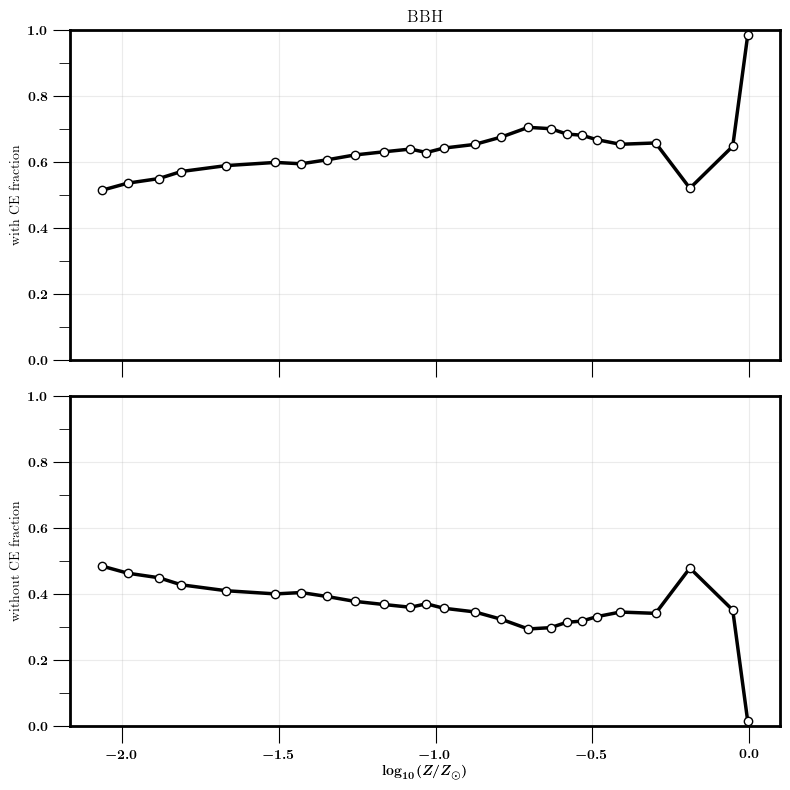

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

processed_digitized_csv = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/data_for_formation_efficiency/processed_channels.csv"

dfd = pd.read_csv(processed_digitized_csv)

for col in ["Channel_I", "Channel_II", "Channel_III"]:
    dfd[col] = pd.to_numeric(dfd[col], errors="coerce").clip(lower=0)

dfd["Total"] = dfd["Channel_I"] + dfd["Channel_II"] + dfd["Channel_III"]
dfd["with_CE"] = dfd["Channel_I"] + dfd["Channel_III"]
dfd["without_CE"] = dfd["Channel_II"]

dfd["f_with_CE"] = np.divide(
    dfd["with_CE"], dfd["Total"],
    out=np.full(len(dfd), np.nan),
    where=(dfd["Total"] > 0)
)
dfd["f_without_CE"] = np.divide(
    dfd["without_CE"], dfd["Total"],
    out=np.full(len(dfd), np.nan),
    where=(dfd["Total"] > 0)
)

dfd = dfd.sort_values("log10Z_Zsun")

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, sharey=True)

axes[0].plot(dfd["log10Z_Zsun"], dfd["f_with_CE"], color="black", lw=2.5)
axes[0].scatter(dfd["log10Z_Zsun"], dfd["f_with_CE"], facecolor="white", edgecolor="black", zorder=3)
axes[0].set_ylabel("with CE fraction")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.25)
axes[0].set_title("BBH")

axes[1].plot(dfd["log10Z_Zsun"], dfd["f_without_CE"], color="black", lw=2.5)
axes[1].scatter(dfd["log10Z_Zsun"], dfd["f_without_CE"], facecolor="white", edgecolor="black", zorder=3)
axes[1].set_ylabel("without CE fraction")
axes[1].set_xlabel(r'$\log_{10}(Z/Z_\odot)$')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.25)

for ax in axes:
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))

plt.tight_layout()
plt.show()

## Van Son 

In [ ]:
Zenodo_data_dir = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/data_for_formation_efficiency'

In [ ]:
# Check if the yield data dictionary exists
if os.path.isfile(f'{Zenodo_data_dir}/vanSon23_yield_data.pkl'):
    print(f'reading in {Zenodo_data_dir}/vanSon23_yield_data.pkl ')
    with open(f'{Zenodo_data_dir}/vanSon23_yield_data.pkl', 'rb') as f:
        yield_data = pickle.load(f)
        
else:
    #########################
    pool = mp.Pool(mp.cpu_count()) # speed up my sending each sim to a different core
    # Apply collect_yield_data to every sim_name
    results = pool.map(collect_yield_data, sim_name_dict.keys()) # results is now a list of yield_data dictionaries

    # Combine the results into a single dictionary
    yield_data = {}
    for sim_name, yield_dict in results:
        yield_data[sim_name] = yield_dict

    # Save the dictionary to a file
    with open(f'{Zenodo_data_dir}/yield_data.pkl', 'wb') as f:
        pickle.dump(yield_data, f)

    print(f'yield_data dictionary saved to {Zenodo_data_dir}/yield_data.pkl' )
    
    
    
# Dictionary to map simulation names to labels and colors we want to use in the plots
sim_name_dict = {
    'NewWinds_RemFryer2012': ['Fiducial', '#5c5c5c', '-.', 'o', 8], 
    'NewWinds_RemMullerMandel': ['MM remnant', '#82BD4D', '-.', '', 4.5],
    'NewWinds_RemFryer2012_noNSBHkick': ['No natal kicks', '#FECC6A', '-.', 'x',4.5],
    'NewWinds_RemFryer2012_noWRwinds': ['No WR winds', '#0597f2', '--', '*',4],
    'NewWinds_RemFryer2012_noMSwinds': ['No MS winds', '#78ccc8', '--', '.',3.5],
    'NewWinds_RemFryer2012_oldRSG': ['Old RSG ', '#C3375A', ':', '',3.5],
    'OldWinds_RemFryer2012': ['Old Winds', '#FF9E7B', ':', 'p',2.5],
    }

# List of DCO flavors
DCO_flavors         = ["BBH", "BHNS", "NSNS"]

In [ ]:
###########################################
# Create a figure
fig = plt.figure(figsize=(20, 15))

# Create a GridSpec with 3 rows (CE, stable and CHE) and 3 columns (BBH, BHNS, NSNS)
gs = GridSpec(3, 3, figure=fig)
axes = [[fig.add_subplot(gs[j, i]) for i in range(3)] for j in range(3)]

# And the DCO flavors we want to plot
titles  = ["BHBH", "BHNS", "NSNS"]

channels = ['CE', 'stable', 'CHE']

# #############################################
# For every simulation
for sim_name, (Lab, color, lines, mark, LW) in sim_name_dict.items(): 

    # select this simulations data
    data = yield_data[sim_name]
    totalMassEvolvedPerMetallicity = data['totalMassEvolvedPerMetallicity']

    # Transpose the axes array so that each sublist represents a column
    axes_transposed = np.transpose(axes)
    #########################
    # Loop over the axes and DCO flavors
    for ax_column, flavor in zip(axes_transposed, DCO_flavors):
        # print(flavor)
        flav_data = data[flavor]

        #####
        # Set the plot values that apply to all axes
        for i, channel in enumerate(channels):
            #Write the channel in the top left corner
            ax_column[i].text(0.85, 0.95, channel + ' channel', transform=ax_column[i].transAxes, fontsize=25, 
            ha = 'right', va='top', color = 'grey', weight = 'bold', alpha = 0.15) # this is repeated because of loop, which is not very pretty, but hence the low alpha
            
            # Plot the data for each channel
            if channel == 'CHE':
                channel += 'stable'
            ax_column[i].plot(np.log10(data['Z_values']/0.014), np.log10(flav_data[f'{channel}_group_lengths']/totalMassEvolvedPerMetallicity), 
                label=Lab, lw=LW, alpha=1, ls=lines, color=color, marker=mark, markevery=2, markersize = 15)
            
            # plot values
            ax_column[i].set_xlim(np.log10(1e-4/0.014),np.log10(0.03/0.014))
            ax_column[i].set_ylim(-8.5,-3.7)

############
# plotvalues
# Exclude chemically homogeneous channel for BHNS and NSNS
axes[2][1].set_visible(False)
axes[2][2].set_visible(False)
# exclude the stable channel for NSNS (Is really super noisy for NSNS! --> exclude)
# axes[1][2].set_visible(False) 

# loop over left column to set ylabels
for ax_row in axes:
    ax_row[0].set_ylabel('$\log_{10} (\eta_{\mathrm{form} \cdot \mathrm{M}_{\odot}}$) ', fontsize =30) 

# loop over top row to set titles
for a_i, ax in enumerate(axes[0]):
    ax.set_title(f'{titles[a_i]} ', fontsize = 22)

# Set the x-axis label for the corners
X_label_axes = [axes[2][0], axes[1][1], axes[1][2]]
for ax in X_label_axes:
    ax.set_xlabel('$\log_{10}(Z/0.014)$', fontsize = 25)

axes[1][1].legend(bbox_to_anchor=(0.2, -0.4), loc='upper left', fontsize = 22, ncols = 2)

# Adjust the space between subplots
plt.subplots_adjust(wspace=0.125, hspace = 0.15)

# plt.savefig(f'../Figures/Yield_variations.pdf', bbox_inches='tight')

plt.show()

### COnvert this to relative fractions:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

###########################################
# Create a figure
fig = plt.figure(figsize=(20, 15))

# Create a GridSpec with 3 rows (CE, stable, CHE) and 3 columns (BBH, BHNS, NSNS)
gs = GridSpec(3, 3, figure=fig)
axes = [[fig.add_subplot(gs[j, i]) for i in range(3)] for j in range(3)]

titles = ["BHBH", "BHNS", "NSNS"]
channels = ['CE', 'stable', 'CHE']

# Optional: whether to plot linear fractions or log10 fractions
plot_log10_fraction = False   # set True if you really want log10 of the fractions

for sim_name, (Lab, color, lines, mark, LW) in sim_name_dict.items():

    data = yield_data[sim_name]
    zvals = np.log10(data['Z_values'] / 0.014)

    axes_transposed = np.transpose(axes)

    for ax_column, flavor in zip(axes_transposed, DCO_flavors):
        flav_data = data[flavor]

        # Read channel efficiencies/yields
        ce_vals = np.asarray(flav_data['CE_group_lengths'], dtype=float)
        stable_vals = np.asarray(flav_data['stable_group_lengths'], dtype=float)

        # CHE exists only as CHEstable_group_lengths in this data structure
        if 'CHEstable_group_lengths' in flav_data:
            che_vals = np.asarray(flav_data['CHEstable_group_lengths'], dtype=float)
        else:
            che_vals = np.zeros_like(ce_vals)

        # Total used to normalize fractions
        if flavor == 'BBH':
            denom = ce_vals + stable_vals + che_vals
        else:
            # BHNS and NSNS: no CHE contribution
            denom = ce_vals + stable_vals

        with np.errstate(divide='ignore', invalid='ignore'):
            frac_ce = np.divide(
                ce_vals, denom,
                out=np.full_like(ce_vals, np.nan, dtype=float),
                where=denom > 0
            )
            frac_stable = np.divide(
                stable_vals, denom,
                out=np.full_like(stable_vals, np.nan, dtype=float),
                where=denom > 0
            )
            frac_che = np.divide(
                che_vals, denom,
                out=np.full_like(che_vals, np.nan, dtype=float),
                where=(denom > 0) if flavor == 'BBH' else np.zeros_like(denom, dtype=bool)
            )

        frac_dict = {
            'CE': frac_ce,
            'stable': frac_stable,
            'CHE': frac_che,
        }

        for i, channel in enumerate(channels):
            ax_column[i].text(
                0.85, 0.95, channel + ' channel',
                transform=ax_column[i].transAxes,
                fontsize=25,
                ha='right', va='top',
                color='grey', weight='bold', alpha=0.15
            )

            yvals = frac_dict[channel]

            # Do not plot CHE for BHNS/NSNS
            if channel == 'CHE' and flavor != 'BBH':
                continue

            if plot_log10_fraction:
                with np.errstate(divide='ignore', invalid='ignore'):
                    yplot = np.log10(yvals)
            else:
                yplot = yvals

            ax_column[i].plot(
                zvals,
                yplot,
                label=Lab,
                lw=LW,
                alpha=1,
                ls=lines,
                color=color,
                marker=mark,
                markevery=2,
                markersize=15
            )

            ax_column[i].set_xlim(np.log10(1e-4/0.014), np.log10(0.03/0.014))

            if plot_log10_fraction:
                ax_column[i].set_ylim(-4.2, 0.1)
            else:
                ax_column[i].set_ylim(0, 1.02)

############
# plotvalues

# Exclude chemically homogeneous channel for BHNS and NSNS
axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

# loop over left column to set ylabels
for ax_row in axes:
    if plot_log10_fraction:
        ax_row[0].set_ylabel(r'$\log_{10}(f_{\mathrm{channel}})$', fontsize=30)
    else:
        ax_row[0].set_ylabel(r'$f_{\mathrm{channel}}$', fontsize=30)

# loop over top row to set titles
for a_i, ax in enumerate(axes[0]):
    ax.set_title(f'{titles[a_i]}', fontsize=22)

# Set the x-axis label for the corners
X_label_axes = [axes[2][0], axes[1][1], axes[1][2]]
for ax in X_label_axes:
    ax.set_xlabel(r'$\log_{10}(Z/0.014)$', fontsize=25)

axes[1][1].legend(
    bbox_to_anchor=(0.2, -0.4),
    loc='upper left',
    fontsize=22,
    ncols=2
)

plt.subplots_adjust(wspace=0.125, hspace=0.15)
plt.show()

## Belczysnki

In [ ]:
# Rough visual digitization of Figure 3 from:
# Belczynski et al. 2022, ApJ, 935, 126
# Figure 3: BH-BH merger formation efficiency per unit mass vs metallicity (Z / Zsun)
#
# IMPORTANT:
# - x-axis is Z / Zsun
# - y-axis is f_BBH [Msun^-1]
# - values below are approximate, visually digitized from the figure
# - intended for rough comparisons / plotting, not precision recovery
# https://iopscience.iop.org/article/10.3847/1538-4357/ac8167/pdf
# final points (highest Z might not be entirely accurate)
data = {
    "Z_over_Zsun": [
        0.02, 0.05, 0.10, 0.15, 0.20,
        0.30, 0.40, 0.50, 0.65, 0.75,
        0.90, 1.05, 1.20, 1.40, 1.70,
        2.00, 2.20
    ],
    "CE": [
        6.2e-5, 5.5e-5, 3.0e-5, 2.3e-5, 1.5e-5,
        8.5e-6, 5.0e-6, 3.2e-6, 1.2e-6, 4.0e-7,
        1.2e-7, 4.0e-8, 1.5e-8, 5.0e-9, 1.0e-9,
        3.0e-10, 1.0e-10
    ],
    "RLOF": [
        1.9e-5, 1.8e-5, 1.5e-5, 1.3e-5, 1.0e-5,
        6.0e-6, 5.0e-6, 4.5e-6, 3.5e-6, 7.0e-6,
        5.5e-6, 3.5e-6, 2.3e-6, 1.1e-6, 4.0e-7,
        1.2e-7, 5.0e-8
    ],
    "RLOF_highIMF": [
        1.7e-5, 1.6e-5, 1.45e-5, 1.2e-5, 1.05e-5,
        7.5e-6, 5.5e-6, 4.8e-6, 3.8e-6, 6.0e-6,
        4.5e-6, 2.7e-6, 1.7e-6, 8.0e-7, 3.0e-7,
        1.0e-7, 4.0e-8
    ],
    "RLOF_highIMF_rapidSN": [
        2.0e-5, 1.9e-5, 1.6e-5, 1.35e-5, 1.1e-5,
        8.5e-6, 6.0e-6, 5.0e-6, 4.0e-6, 8.5e-6,
        6.5e-6, 4.2e-6, 2.8e-6, 1.3e-6, 5.0e-7,
        1.5e-7, 6.0e-8
    ],
}

df = pd.DataFrame(data)

print(df)

# Optional: save
df.to_csv("figure3_digitized_corrected.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(df["Z_over_Zsun"], df["CE"], label="CE")
ax.plot(df["Z_over_Zsun"], df["RLOF"], label="RLOF")
ax.plot(df["Z_over_Zsun"], df["RLOF_highIMF"], label="RLOF + high IMF")
ax.plot(df["Z_over_Zsun"], df["RLOF_highIMF_rapidSN"], label="RLOF + high IMF + rapid SN")

ax.set_yscale("log")
ax.set_xlabel(r"$Z/Z_{\odot}$")
ax.set_ylabel(r"$f_{\rm BBH}\ [{\rm M}_{\odot}^{-1}]$")
ax.set_title("Approximate digitization of Figure 3")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.3)
ax.set_ylim(5E-6, 7*1E-5)

plt.tight_layout()
plt.show()

### Ioro 2022 



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D


LABELMAP = {
    "BHBH": "BBH",
    "BHBHm": "BBH",
    "NSNS": "BNS",
    "NSNSm": "BNS",
    "BHNS": "BHNS",
    "BHNSm": "BHNS",
}

LABEL_SIZE = 15


def compute_collapsed_fractions(
    df,
    alpha,
    bco_type,
    min_with_ce_count_bns=1,
    min_total_count_bns=1,
    mask_zero_bns=True,
):
    """
    Return:
      with_CE    = CI + CIII + CIV
      without_CE = CII
      others     = 1 - (with_CE + without_CE)

    as a function of Z for a given alpha and compact-object type.

    For BNS only, optionally mask points where the absolute number of
    systems contributing to the with-CE channel is too small.
    """
    sub = df[df["alpha"] == alpha].sort_values("Z")
    if sub.empty:
        return None

    z = sub["Z"].to_numpy(dtype=float)
    tot = sub[bco_type].to_numpy(dtype=float)
    ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
    cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
    ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
    civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

    with_ce_count = ci + ciii + civ

    with np.errstate(divide="ignore", invalid="ignore"):
        f_i = np.divide(ci, tot, out=np.full_like(ci, np.nan), where=tot > 0)
        f_ii = np.divide(cii, tot, out=np.full_like(cii, np.nan), where=tot > 0)
        f_iii = np.divide(ciii, tot, out=np.full_like(ciii, np.nan), where=tot > 0)
        f_iv = np.divide(civ, tot, out=np.full_like(civ, np.nan), where=tot > 0)

    f_with_ce = f_i + f_iii + f_iv
    f_without_ce = f_ii
    f_others = 1.0 - (f_with_ce + f_without_ce)

    # ---------------------------------------------------------
    # Mask unreliable BNS with-CE fractions
    # ---------------------------------------------------------
    if bco_type in {"NSNS", "NSNSm"}:
        bad = np.zeros_like(z, dtype=bool)

        if min_with_ce_count_bns is not None:
            bad |= (with_ce_count < min_with_ce_count_bns)

        if min_total_count_bns is not None:
            bad |= (tot < min_total_count_bns)

        if mask_zero_bns:
            bad |= (with_ce_count <= 0)

        # Only mask the with-CE curve
        f_with_ce = f_with_ce.astype(float)
        f_with_ce[bad] = np.nan

    return {
        "Z": z,
        "with_CE": f_with_ce,
        "without_CE": f_without_ce,
        "others": f_others,
    }


def format_axis(ax, row_idx, nrows, ylabel):
    ax.set_xscale("log")
    ax.set_xlim(1e-4, 0.03)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.grid(which="both", lw=0.25, alpha=0.5)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)

    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)

    if row_idx == nrows - 1:
        ax.set_xlabel("$Z$", fontsize=LABEL_SIZE)
    else:
        ax.tick_params(labelbottom=False)


def make_overlay_figure(
    model_dic,
    my_loc=None,
    merging=True,
    which_fraction="with_CE",
    figsize=(11, 12),
    save=True,
    output_name=None,
):
    """
    Create one big figure with 3 rows:
      BBH
      BNS
      BHNS

    All models and all alphas are overlaid in each panel.

    Parameters
    ----------
    which_fraction : str
        "with_CE" or "without_CE"
    """
    if which_fraction not in {"with_CE", "without_CE"}:
        raise ValueError("which_fraction must be 'with_CE' or 'without_CE'")

    bco_types = ("BHBHm", "NSNSm", "BHNSm") if merging else ("BHBH", "NSNS", "BHNS")

    # collect all alpha values across all models
    all_alphas = set()
    for model, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if os.path.exists(summary_file):
            df = pd.read_csv(summary_file)
            all_alphas.update(df["alpha"].dropna().unique())

    all_alphas = sorted(all_alphas)

    # styles:
    #   color = model
    #   linestyle = alpha
    cmap = plt.get_cmap("tab20")
    model_names = list(model_dic.keys())
    model_colors = {model: cmap(i % 20) for i, model in enumerate(model_names)}

    linestyle_cycle = ["-", "--", "-.", ":"]
    alpha_linestyles = {
        alpha: linestyle_cycle[i % len(linestyle_cycle)]
        for i, alpha in enumerate(all_alphas)
    }

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes)

    for row_idx, bco_type in enumerate(bco_types):
        ax = axes[row_idx]

        for model, path in model_dic.items():
            summary_file = os.path.join(path, "summary.csv")
            if not os.path.exists(summary_file):
                print(f"Warning: missing file {summary_file}")
                continue

            df = pd.read_csv(summary_file)
            alphas = sorted(df["alpha"].dropna().unique())

            for alpha in alphas:
                result = compute_collapsed_fractions(df, alpha, bco_type)
                if result is None:
                    continue

                ax.plot(
                    result["Z"],
                    result[which_fraction],
                    color=model_colors[model],
                    linestyle=alpha_linestyles[alpha],
                    lw=2.0,
                    alpha=0.95,
                )

        ylabel = f"$f_\\mathrm{{{LABELMAP[bco_type]}}}$"
        format_axis(ax, row_idx, len(bco_types), ylabel)

        panel_title = LABELMAP[bco_type]
        ax.text(
            0.02, 0.92, panel_title,
            transform=ax.transAxes,
            fontsize=LABEL_SIZE,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
        )

    if which_fraction == "with_CE":
        fig.suptitle("Fraction forming with CE", fontsize=LABEL_SIZE + 2, y=0.995)
    else:
        fig.suptitle("Fraction forming without CE", fontsize=LABEL_SIZE + 2, y=0.995)

    # legends
    model_handles = [
        Line2D([0], [0], color=model_colors[model], lw=2.5, label=model)
        for model in model_names
    ]
    alpha_handles = [
        Line2D([0], [0], color="black", lw=2.5, linestyle=alpha_linestyles[alpha], label=rf"$\alpha_{{CE}}={alpha}$")
        for alpha in all_alphas
    ]

    fig.legend(
        handles=model_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=min(6, max(1, len(model_handles))),
        frameon=False,
        fontsize=LABEL_SIZE - 3,
        title="Model",
        title_fontsize=LABEL_SIZE - 2,
    )

    fig.legend(
        handles=alpha_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.925),
        ncol=min(4, max(1, len(alpha_handles))),
        frameon=False,
        fontsize=LABEL_SIZE - 3,
        title=r"$\alpha_{\mathrm{CE}}$",
        title_fontsize=LABEL_SIZE - 2,
    )

    fig.tight_layout(rect=[0.04, 0.04, 0.98, 0.88])

    if save:
        if output_name is None:
            output_name = f"overlay_{which_fraction}.pdf"
        fig.savefig(output_name, bbox_inches="tight")

    return fig, axes


# -------------------------------------------------------------------
# paths
# -------------------------------------------------------------------

my_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"

model_dic = {
    "F": os.path.join(my_loc, "simulation_F"),
    "QCBSE": os.path.join(my_loc, "simulation_QCBSE"),
    "QCBB": os.path.join(my_loc, "simulation_QCBB"),
    "RBSE": os.path.join(my_loc, "simulation_RBSE"),
    "NTC": os.path.join(my_loc, "simulation_NTC"),
    "NT": os.path.join(my_loc, "simulation_NT"),
    "QHE": os.path.join(my_loc, "simulation_QHE"),
    "F19": os.path.join(my_loc, "simulation_F19"),
    "K150": os.path.join(my_loc, "simulation_K150"),
    "K265": os.path.join(my_loc, "simulation_K265"),
    "LX": os.path.join(my_loc, "simulation_LX"),
    "LK": os.path.join(my_loc, "simulation_LK"),
    "LC": os.path.join(my_loc, "simulation_LC"),
    "SND": os.path.join(my_loc, "simulation_SND"),
    "OPT": os.path.join(my_loc, "simulation_OPT"),
    "F5M": os.path.join(my_loc, "simulation_F5M"),
}

# -------------------------------------------------------------------
# make the two figures
# -------------------------------------------------------------------

fig1, axes1 = make_overlay_figure(
    model_dic=model_dic,
    merging=True,
    which_fraction="with_CE",
    figsize=(11, 12),
    save=True,
    output_name="all_models_with_CE.pdf",
)

fig2, axes2 = make_overlay_figure(
    model_dic=model_dic,
    merging=True,
    which_fraction="without_CE",
    figsize=(11, 12),
    save=True,
    output_name="all_models_without_CE.pdf",
)

plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


CHANNEL_COLORS = {
    "with_CE": "blueviolet",
    "without_CE": "palevioletred",
    "Others": "gray",
}

LABELMAP = {
    "BHBH": "BBH",
    "BHBHm": "BBHm",
    "NSNS": "BNS",
    "NSNSm": "BNSm",
    "BHNS": "BHNS",
    "BHNSm": "BHNSm",
}

LABEL_SIZE = 16


def compute_channel_fractions(df, alphas, bco_type):
    """
    Sum over one or more alpha values, then return:
      - with_CE     = CI + CIII + CIV
      - without_CE  = CII
      - others      = 1 - (with_CE + without_CE)
    as a function of Z.
    """
    alphas = np.atleast_1d(alphas)

    x = None
    n_tot = None
    ch_i = None
    ch_ii = None
    ch_iii = None
    ch_iv = None

    for alpha in alphas:
        sub = df[df["alpha"] == alpha].sort_values("Z")
        if sub.empty:
            continue

        z = sub["Z"].to_numpy(dtype=float)
        tot = sub[bco_type].to_numpy(dtype=float)
        ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
        cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
        ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
        civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

        if x is None:
            x = z
            n_tot = tot
            ch_i = ci
            ch_ii = cii
            ch_iii = ciii
            ch_iv = civ
        else:
            n_tot += tot
            ch_i += ci
            ch_ii += cii
            ch_iii += ciii
            ch_iv += civ

    if x is None:
        raise ValueError(f"No data found for alphas={alphas} and bco_type={bco_type}")

    with np.errstate(divide="ignore", invalid="ignore"):
        f_i = np.divide(ch_i, n_tot, out=np.zeros_like(ch_i), where=n_tot > 0)
        f_ii = np.divide(ch_ii, n_tot, out=np.zeros_like(ch_ii), where=n_tot > 0)
        f_iii = np.divide(ch_iii, n_tot, out=np.zeros_like(ch_iii), where=n_tot > 0)
        f_iv = np.divide(ch_iv, n_tot, out=np.zeros_like(ch_iv), where=n_tot > 0)

    f_with_ce = f_i + f_iii + f_iv
    f_without_ce = f_ii
    f_others = 1.0 - (f_with_ce + f_without_ce)

    return x, f_with_ce, f_without_ce, f_others


def plot_aoe(ax, df, alphas, bco_type, label=True):
    """
    Plot absolute fractions for:
      - with CE
      - without CE
      - Others
    """
    x, f_with_ce, f_without_ce, f_others = compute_channel_fractions(df, alphas, bco_type)

    ax.plot(
        x, f_with_ce,
        lw=2.5,
        color=CHANNEL_COLORS["with_CE"],
        marker="o",
        ms=4,
        label="with CE" if label else None,
    )
    ax.plot(
        x, f_without_ce,
        lw=2.5,
        color=CHANNEL_COLORS["without_CE"],
        marker="s",
        ms=4,
        label="without CE" if label else None,
    )
    ax.plot(
        x, f_others,
        lw=2.0,
        color=CHANNEL_COLORS["Others"],
        ls=":",
        marker="D",
        ms=3.5,
        label="Others" if label else None,
    )


def format_panel(ax, row_idx, col_idx, alpha, bco_type):
    ax.set_xscale("log")
    ax.set_xlim(1e-4, 0.03)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.grid(which="both", lw=0.2)

    if col_idx == 0:
        ax.set_ylabel(f"$f_\\mathrm{{{LABELMAP[bco_type]}}}$", fontsize=LABEL_SIZE)
        ax.tick_params(
            axis="y",
            which="both",
            right=True,
            direction="in",
            top=True,
            left=True,
            labelright=False,
            labelleft=True,
        )
    else:
        ax.tick_params(
            axis="y",
            which="both",
            right=True,
            direction="in",
            top=True,
            left=True,
            labelright=False,
            labelleft=False,
        )

    if row_idx == 2:
        ax.set_xlabel("$Z$", fontsize=LABEL_SIZE)
        ax.tick_params(
            axis="x",
            which="both",
            right=True,
            direction="in",
            top=True,
            labeltop=False,
            labelbottom=True,
        )
    else:
        ax.tick_params(
            axis="x",
            which="both",
            right=True,
            direction="in",
            top=True,
            labeltop=False,
            labelbottom=False,
        )

    if row_idx == 0:
        ax.set_title(f"$\\alpha_\\mathrm{{CE}}={alpha}$", fontsize=LABEL_SIZE)


def multiplot_channel_aoe(path, model, merging=True, legend_on=(0, 0), save=True):
    summary_file = os.path.join(path, "summary.csv")
    df = pd.read_csv(summary_file)

    bco_types = ("BHBHm", "NSNSm", "BHNSm") if merging else ("BHBH", "NSNS", "BHNS")
    alphas = np.sort(df["alpha"].unique())

    fig, axes = plt.subplots(
        nrows=len(bco_types),
        ncols=len(alphas),
        figsize=(15, 10),
        sharex=False,
        sharey=False,
    )

    axes = np.atleast_2d(axes)

    for row_idx, bco_type in enumerate(bco_types):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]
            plot_aoe(
                ax,
                df,
                alpha,
                bco_type,
                label=(row_idx == 0 and col_idx == 0),
            )
            format_panel(ax, row_idx, col_idx, alpha, bco_type)

    leg_row, leg_col = legend_on
    axes[leg_row, leg_col].legend(ncol=1, fontsize=LABEL_SIZE - 4, frameon=False)

    fig.tight_layout()

    if save:
        fig.savefig(f"plot_channel_aoe_{model}.pdf", bbox_inches="tight")

    return fig, axes


my_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"

model_dic = {
    "F": os.path.join(my_loc, "simulation_F"),
    "QCBSE": os.path.join(my_loc, "simulation_QCBSE"),
    "QCBB": os.path.join(my_loc, "simulation_QCBB"),
    "RBSE": os.path.join(my_loc, "simulation_RBSE"),
    "NTC": os.path.join(my_loc, "simulation_NTC"),
    "NT": os.path.join(my_loc, "simulation_NT"),
    "QHE": os.path.join(my_loc, "simulation_QHE"),
    "F19": os.path.join(my_loc, "simulation_F19"),
    "K150": os.path.join(my_loc, "simulation_K150"),
    "K265": os.path.join(my_loc, "simulation_K265"),
    "LX": os.path.join(my_loc, "simulation_LX"),
    "LK": os.path.join(my_loc, "simulation_LK"),
    "LC": os.path.join(my_loc, "simulation_LC"),
    "SND": os.path.join(my_loc, "simulation_SND"),
    "OPT": os.path.join(my_loc, "simulation_OPT"),
    "F5M": os.path.join(my_loc, "simulation_F5M"),
}

for model, path in model_dic.items():
    fig, axes = multiplot_channel_aoe(path, model)
    plt.show(fig)
    plt.close(fig)
    
    

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
#                                AutoMinorLocator,LogLocator)

# import matplotlib as mpl
# label_size =18
# mpl.rcParams['xtick.labelsize'] = label_size
# mpl.rcParams['ytick.labelsize'] = label_size
# #mpl.rcParams['mathtext.default']='regular'
# mpl.rcParams.update({'figure.autolayout': True})
# mpl.rcParams['contour.negative_linestyle'] = 'solid'
# mpl.rcParams['axes.facecolor'] = 'white'
# mpl.rcParams['xtick.major.size'] = 10
# mpl.rcParams['xtick.major.width'] = 1.5
# mpl.rcParams['xtick.minor.size'] = 5
# mpl.rcParams['xtick.minor.width'] = 1
# mpl.rcParams['ytick.major.size'] = 10
# mpl.rcParams['ytick.major.width'] = 1.5
# mpl.rcParams['ytick.minor.size'] = 5
# mpl.rcParams['ytick.minor.width'] = 1
# import warnings
# warnings.filterwarnings('ignore')
# import subprocess
# import warnings
# warnings.filterwarnings('ignore')
# import subprocess

# import matplotlib.colors as colors

# import sys

# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator


# CHANNEL_COLORS = {
#     "CI": "blueviolet",
#     "CII": "palevioletred",
#     "CIII": "sandybrown",
#     "CIV": "darkblue",
#     "Others": "gray",
#     "CK": "black",
# }

# LABELMAP = {
#     "BHBH": "BBH",
#     "BHBHm": "BBHm",
#     "NSNS": "BNS",
#     "NSNSm": "BNSm",
#     "BHNS": "BHNS",
#     "BHNSm": "BHNSm",
# }

# LABEL_SIZE = 16


# def compute_channel_fractions(df, alphas, bco_type):
#     """
#     Sum over one or more alpha values, then return the absolute
#     fraction in each formation channel as a function of Z.
#     """
#     alphas = np.atleast_1d(alphas)

#     x = None
#     n_tot = None
#     ch_i = None
#     ch_ii = None
#     ch_iii = None
#     ch_iv = None
#     n_k = None

#     for alpha in alphas:
#         sub = df[df["alpha"] == alpha].sort_values("Z")
#         if sub.empty:
#             continue

#         z = sub["Z"].to_numpy(dtype=float)
#         tot = sub[bco_type].to_numpy(dtype=float)
#         ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
#         cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
#         ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
#         civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)
#         ck = (
#             sub[f"{bco_type}K1"].to_numpy(dtype=float)
#             + sub[f"{bco_type}K2"].to_numpy(dtype=float)
#             + sub[f"{bco_type}K3"].to_numpy(dtype=float)
#         )

#         if x is None:
#             x = z
#             n_tot = tot
#             ch_i = ci
#             ch_ii = cii
#             ch_iii = ciii
#             ch_iv = civ
#             n_k = ck
#         else:
#             n_tot += tot
#             ch_i += ci
#             ch_ii += cii
#             ch_iii += ciii
#             ch_iv += civ
#             n_k += ck

#     if x is None:
#         raise ValueError(f"No data found for alphas={alphas} and bco_type={bco_type}")

#     with np.errstate(divide="ignore", invalid="ignore"):
#         f_i = np.divide(ch_i, n_tot, out=np.zeros_like(ch_i), where=n_tot > 0)
#         f_ii = np.divide(ch_ii, n_tot, out=np.zeros_like(ch_ii), where=n_tot > 0)
#         f_iii = np.divide(ch_iii, n_tot, out=np.zeros_like(ch_iii), where=n_tot > 0)
#         f_iv = np.divide(ch_iv, n_tot, out=np.zeros_like(ch_iv), where=n_tot > 0)
#         f_k = np.divide(n_k, n_tot, out=np.zeros_like(n_k), where=n_tot > 0)

#     f_other = 1.0 - (f_i + f_ii + f_iii + f_iv)

#     return x, f_i, f_ii, f_iii, f_iv, f_other, f_k


# def plot_aoe(ax, df, alphas, bco_type, collisions=False, label=True):
#     """
#     Plot absolute channel fractions (not stacked).
#     """
#     x, f_i, f_ii, f_iii, f_iv, f_other, f_k = compute_channel_fractions(df, alphas, bco_type)

#     ax.plot(
#         x, f_i, lw=2.5, color=CHANNEL_COLORS["CI"],
#         label="CI" if label else None
#     )
#     ax.plot(
#         x, f_ii, lw=2.5, color=CHANNEL_COLORS["CII"],
#         label="CII" if label else None
#     )
#     ax.plot(
#         x, f_iii, lw=2.5, color=CHANNEL_COLORS["CIII"],
#         label="CIII" if label else None
#     )
#     ax.plot(
#         x, f_iv, lw=2.5, color=CHANNEL_COLORS["CIV"],
#         label="CIV" if label else None
#     )
#     ax.plot(
#         x, f_other, lw=2.0, color=CHANNEL_COLORS["Others"], ls=":",
#         label="Others" if label else None
#     )

#     if collisions:
#         ax.plot(
#             x, f_k, lw=2.5, color=CHANNEL_COLORS["CK"], ls="--",
#             label="CK" if label else None
#         )


# def format_panel(ax, row_idx, col_idx, alpha, bco_type):
#     ax.set_xscale("log")
#     ax.set_xlim(1e-4, 0.03)
#     ax.set_ylim(0, 1.0)
#     ax.yaxis.set_minor_locator(MultipleLocator(0.05))
#     ax.yaxis.set_major_locator(MultipleLocator(0.25))
#     ax.grid(which="both", lw=0.2)

#     if col_idx == 0:
#         ax.set_ylabel(f"$f_\\mathrm{{{LABELMAP[bco_type]}}}$", fontsize=LABEL_SIZE)
#         ax.tick_params(
#             axis="y", which="both",
#             right=True, direction="in", top=True, left=True,
#             labelright=False, labelleft=True
#         )
#     else:
#         ax.tick_params(
#             axis="y", which="both",
#             right=True, direction="in", top=True, left=True,
#             labelright=False, labelleft=False
#         )

#     if row_idx == 2:
#         ax.set_xlabel("$Z$", fontsize=LABEL_SIZE)
#         ax.tick_params(
#             axis="x", which="both",
#             right=True, direction="in", top=True,
#             labeltop=False, labelbottom=True
#         )
#     else:
#         ax.tick_params(
#             axis="x", which="both",
#             right=True, direction="in", top=True,
#             labeltop=False, labelbottom=False
#         )

#     if row_idx == 0:
#         ax.set_title(f"$\\alpha_\\mathrm{{CE}}={alpha}$", fontsize=LABEL_SIZE)


# def multiplot_channel_aoe(path, model, merging=True, legend_on=(0, 0), save=True):
#     summary_file = os.path.join(path, "summary.csv")
#     df = pd.read_csv(summary_file)

#     bco_types = ("BHBHm", "NSNSm", "BHNSm") if merging else ("BHBH", "NSNS", "BHNS")
#     alphas = np.sort(df["alpha"].unique())

#     fig, axes = plt.subplots(
#         nrows=len(bco_types),
#         ncols=len(alphas),
#         figsize=(15, 10),
#         sharex=False,
#         sharey=False
#     )

#     axes = np.atleast_2d(axes)

#     for row_idx, bco_type in enumerate(bco_types):
#         for col_idx, alpha in enumerate(alphas):
#             ax = axes[row_idx, col_idx]
#             plot_aoe(
#                 ax,
#                 df,
#                 alpha,
#                 bco_type,
#                 collisions=True,
#                 label=(row_idx == 0 and col_idx == 0)
#             )
#             format_panel(ax, row_idx, col_idx, alpha, bco_type)

#     leg_row, leg_col = legend_on
#     axes[leg_row, leg_col].legend(ncol=2, fontsize=LABEL_SIZE - 6, frameon=False)

#     fig.tight_layout()

#     if save:
#         fig.savefig(f"plot_channel_aoe_{model}.pdf", bbox_inches="tight")

#     return fig, axes


# my_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"

# model_dic = {
#     "F": os.path.join(my_loc, "simulation_F"),
#     "QCBSE": os.path.join(my_loc, "simulation_QCBSE"),
#     "QCBB": os.path.join(my_loc, "simulation_QCBB"),
#     "RBSE": os.path.join(my_loc, "simulation_RBSE"),
#     "NTC": os.path.join(my_loc, "simulation_NTC"),
#     "NT": os.path.join(my_loc, "simulation_NT"),
#     "QHE": os.path.join(my_loc, "simulation_QHE"),
#     "F19": os.path.join(my_loc, "simulation_F19"),
#     "K150": os.path.join(my_loc, "simulation_K150"),
#     "K265": os.path.join(my_loc, "simulation_K265"),
#     "LX": os.path.join(my_loc, "simulation_LX"),
#     "LK": os.path.join(my_loc, "simulation_LK"),
#     "LC": os.path.join(my_loc, "simulation_LC"),
#     "SND": os.path.join(my_loc, "simulation_SND"),
#     "OPT": os.path.join(my_loc, "simulation_OPT"),
#     "F5M": os.path.join(my_loc, "simulation_F5M"),
# }

# for model, path in model_dic.items():
#     fig, axes = multiplot_channel_aoe(path, model)
#     plt.show(fig)
#     plt.close(fig)

In [ ]:
# data lives here  
# 

### Broekgaarden 

In [ ]:
# # with the saved calculated yields per formation channel and metallicity in the location: /Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/formation_channels_per_Z_hdf5weights_DCOname.csv
    
# #



# def plotGridFormationRatePerMetallicity_grouped(
#     DCOtype='BBH',
#     Ylim=10,
#     csvPath=None,
#     plot_stacked=True,
#     plot_fraction=False,
#     include_vii_in_with_CE=False,
# ):
#     dictDCOtypeDCOlabel = {'BBH': 'BHBH', 'BNS': 'NSNS', 'BHNS': 'BHNS', 'NSBH': 'NSBH'}
#     DCOname = dictDCOtypeDCOlabel[DCOtype]

#     print('doing DCO type', DCOtype)

#     csv_file = os.path.join(csvPath, f'formation_channels_per_Z_hdf5weights_{DCOname}.csv')
#     log10metallicities = np.log10(np.asarray(metallicities_list))
#     BPSnameslist = list(string.ascii_uppercase)[0:nModels]

#     ncols, nrows = 3, 7
#     f, axe = plt.subplots(
#         ncols=ncols,
#         nrows=nrows,
#         figsize=(22, 26),
#         gridspec_kw={"width_ratios": 1*np.ones(ncols), "height_ratios": 1*np.ones(nrows)}
#     )

#     grouped_labels = ['with CE', 'without CE', 'other']
#     grouped_colors = ['tab:red', 'tab:blue', 'gray']

#     for ind_m, bps_model in enumerate(BPSnameslist):
#         ii, jj = int(ind_m / ncols) % nrows, ind_m % ncols

#         grouped = load_grouped_formation_channels(
#             csv_file=csv_file,
#             bps_model=bps_model,
#             headerDict_Z_rev=headerDict_Z_rev,
#             include_vii_in_with_CE=include_vii_in_with_CE,
#         )

#         grouped_rates = [
#             grouped['with_CE'],
#             grouped['without_CE'],
#             grouped['other'],
#         ]

#         axe[ii, jj] = plotFormationChannelsGroupedSingle(
#             axe=axe[ii, jj],
#             metallicities=log10metallicities,
#             grouped_rates=grouped_rates,
#             colorlist=grouped_colors,
#             labels=grouped_labels,
#             BPSmodelname=bps_model,
#             Ylim=Ylim,
#             DCOtype=DCOtype,
#             plot_stacked=plot_stacked,
#             plot_fraction=plot_fraction,
#         )

#     fs_label = 20
#     ylabel = r'$\eta \ \  [10^{-5}\ \rm{M}_{\odot}^{-1}]\  $'
#     xlabel = r'$\log_{10}(Z_{\rm{i}})$'
#     if plot_fraction:
#         ylabel = r'$\textbf{fraction}$'

#     for ii in range(nrows-1):
#         axe[ii,0] = layoutAxesNoXlabel(axe[ii,0], nameX=None, nameY=ylabel, fontsize=fs_label)
#     axe[nrows-1,0] = layoutAxes(axe[nrows-1,0], nameX=xlabel, nameY=ylabel, fontsize=fs_label)

#     for ii in range(nrows-1):
#         axe[ii,1] = layoutAxesNoXandYlabel(axe[ii,1], nameX=None, nameY=None, fontsize=fs_label)
#     axe[nrows-1,1] = layoutAxesNoYlabel(axe[nrows-1,1], nameX=xlabel, nameY='xx', fontsize=fs_label)

#     for ii in range(nrows-2):
#         axe[ii,2] = layoutAxesNoXandYlabel(axe[ii,2], nameX=None, nameY=None, fontsize=fs_label)

#     axe[nrows-2,2] = layoutAxesNoYlabel(axe[nrows-2,2], nameX=xlabel, nameY=None, fontsize=fs_label)
#     axe[nrows-1,2].axis('off')
#     axe[nrows-2,2].set_zorder(100)

#     for ii in range(nrows-2):
#         axe[ii,2].tick_params(labelbottom=False, labelleft=False)
#     for ii in range(nrows-1):
#         axe[ii,1].tick_params(labelbottom=False, labelleft=False)
#     for ii in range(nrows-1):
#         axe[ii,0].tick_params(labelbottom=False)

#     axe[nrows-1,1].tick_params(labelleft=False)
#     axe[nrows-2,2].tick_params(labelleft=False)

#     plt.tight_layout()
#     plt.subplots_adjust(wspace=0.05, hspace=0.05)

#     stack_str = 'stacked' if plot_stacked else 'notstacked'
#     fract_str = '_fraction' if plot_fraction else '_yield'

#     plt.savefig(f'./FormationRatePerZ_{DCOname}_grouped_{stack_str}{fract_str}.pdf')
#     plt.show()
#     plt.close()

    
# def plotFormationChannelsPerMetallicitySingle(axe=[], metallicities=[0.001, 0.33], formationRates=[0,0], colorlist=['k'], totalcolor='k', BPSmodelname='A',Ylim=3.85, DCOtype='BBH', plot_stacked=True, plot_fraction=False):
#     """
    
#     plots a single panel with formation channel yields per metallicity
    
#     """
    
#     # start building from 0
#     upperY = np.zeros_like(formationRates[0])
#     lowerY = np.zeros_like(formationRates[0])
    
#     # go over rates of channels
#     total = 0 
#     for ind_c, c_rate in enumerate(formationRates):
#         total += c_rate 
    
#     total_sum = np.sum(total)
    
    
#     plotfactor_higher=False
#     if plot_fraction==False:
#         if (DCOtype=='BNS') & (BPSmodelname in [ "E", "H"]):
#             plotfactor_higher=10
#         # multiply the rate by a factor 10 (or chosen factor) to make the yields visible in the large figure
#         elif (DCOtype=='BHNS') & (BPSmodelname in [ "E", "G"]):
#             plotfactor_higher=10        
    
    
#     for ind_c, c_rate in enumerate(formationRates[:]):
        
        
#         if plot_fraction==True:
#             fc_plot_rate = c_rate/total # take the fraction
# #                 print('between 0 1 ', c_rate)
#         else:
#             fc_plot_rate = c_rate*1e5
        
#         # add this rate, 
#         if plotfactor_higher==False:
#             upperY += fc_plot_rate
#         else:
#             upperY+= fc_plot_rate*plotfactor_higher
            
        
        
#         percentage = (np.sum(c_rate) / total_sum)*100.
#         percentage_str =  r'$%s$'%str((roundAndFormat1(percentage))) + str(r'\%')
        
        
#         if plot_stacked==True:
#         # 1e5 to make the numbers nice
# #             print('ind_c ', ind_c)
# #             print('lowerY, ', lowerY)
# #             print('upperY', upperY.values)
#             axe.fill_between(metallicities, lowerY, upperY, facecolor=colorlist[ind_c], \
#                       lw=3, alpha=1, label=percentage_str)
# #             axe.plot(metallicities, lowerY, lw=5, color='blue')
# #             axe.plot(metallicities, upperY, lw=5, color='red')
#         else:
            
#             if plotfactor_higher==False:
#                 axe.plot(metallicities, fc_plot_rate, color=colorlist[ind_c], \
#                           lw=3, alpha=1, label=percentage_str)  
#             else:
#                 axe.plot(metallicities, fc_plot_rate*plotfactor_higher, color=colorlist[ind_c], \
#                           lw=3, alpha=1, label=percentage_str)              
        
#         if plotfactor_higher==False:
#             lowerY += fc_plot_rate
#         else:
#             lowerY += fc_plot_rate*plotfactor_higher    
            
    
    
#     ### second axes ###
# #     if plot_fraction==True:
# #         ax2y = axe.twinx()
# #         ylabel2 =  r'$\eta \ \  [10^{-5}\ \rm{M}_{\odot}^{-1}]\  $'   
# #         ax2y.set_ylim(bottom=0,top=8)
# #         cdfcolor='k'
# #         ax2y.plot(metallicities, total*1E5, color=cdfcolor, lw=3, alpha=1, linestyle=':')

# #         ax2y.tick_params(labelsize=fs-4, colors=cdfcolor)
# #         ax2y.set_ylabel(ylabel2, fontsize=fs, color=cdfcolor) 
        

    
    
#     ######## AXES LABELS, LEGENDS, LIMS,  ###########
#     # plot extra vertical line to indicate metallicities   
#     for zz_ind, zz in enumerate(metallicity_vlines_values_list) :
#         axe.plot([zz,zz], [0,Ylim+1], \
#                          c='k',\
#                          lw=1.2, alpha=1, linestyle=':', zorder=100)   
#         axe.text(zz-0.06, Ylim-0.022, s=metallicity_vlines_text_list[zz_ind], fontsize=fs-8.5, rotation=90, verticalalignment='top')   

    
#     # location of the small legends is on the left, unless it does not fit:
#     if DCOtype=='BBH':
#         x_box, y_box = 0.63, .4
#     elif (DCOtype=='BNS') and (BPSmodelname=='G'):
#         x_box, y_box = 0.63, .4
#     else:
#         x_box, y_box = 0.01, .47
    
#     if plot_fraction==False:
#         axe.legend(fontsize=14,  ncol=2, \
#                    bbox_to_anchor=(x_box, y_box),loc="lower left", borderaxespad=0., frameon=False).set_zorder(10000)
   
#     axe.set_xlim(min(metallicities), max(metallicities))
#     axe.set_ylim(0,Ylim)
        
#     bbox_props = dict(boxstyle="round", fc="w", ec="0.5", alpha=0.95)
#     axe.annotate(r'\textbf{model %s:}'%(BPSmodelname) +'\n' + alphabetPhysicalNameDict[BPSmodelname], xy=(0.022, .95),\
#                  xycoords='axes fraction', fontsize = fs, weight = 'bold', ha='left', va="top",bbox=bbox_props,\
#                 zorder=1E10)

#     if plotfactor_higher!=False:
#         axe.annotate(r'\textbf{%s}'%(plotfactor_higher) +r'$\times$',  xy=(0.88, .15),\
#                      xycoords='axes fraction', fontsize = fs+5, weight = 'bold', ha='left', va="top", zorder=1E10)        

    
#     return axe
    
    
    

# def plotGridFormationRatePerMetallicity(
#     DCOtype='BBH',
#     Ylim=10,
#     csvPath=None,
#     plot_stacked=True,
#     plot_fraction=False
#     ):

#     channel_names = ['classic', 'stable B no CEE', 'vii', 'immediate CE', 'double-core CE', 'other']
#     colorlist = [channelColorDict[i] for i in channel_names]

#     dictDCOtypeDCOlabel = {'BBH':'BHBH', 'BNS':'NSNS', 'BHNS':'BHNS', 'NSBH':'NSBH'}
#     DCOname = dictDCOtypeDCOlabel[DCOtype]

#     print('doing DCO type ', DCOtype)

#     # 👉 build path from user input
#     csv_file = f"{csvPath}/formation_channels_per_Z_hdf5weights_{DCOname}.csv"

#     # 👉 read ONCE
#     df = pd.read_csv(csv_file, index_col=0)

#     BPSnameslist = list(string.ascii_uppercase)[0:nModels]
#     log10metallicities = np.log10(np.asarray(metallicities_list))

#     ncols, nrows = 3, 7
#     f, axe = plt.subplots(
#         ncols=ncols,
#         nrows=nrows,
#         figsize=(22,26),
#         gridspec_kw={"width_ratios":1*np.ones(ncols), "height_ratios":1*np.ones(nrows)}
#     )

#     for ind_m, bps_model in enumerate(BPSnameslist[:]):

#         ii, jj = int(ind_m/ncols) % nrows, ind_m % ncols

#         formationRates = []

#         for c_ in channel_names:
#             key_ = bps_model + ' ' + headerDict_Z_rev[c_] + '  [Msun^{-1}]'
#             formationRates.append(df[key_])

#         axe[ii, jj] = plotFormationChannelsPerMetallicitySingle(
#             axe=axe[ii, jj],
#             metallicities=log10metallicities,
#             formationRates=formationRates,
#             colorlist=colorlist,
#             BPSmodelname=bps_model,
#             Ylim=Ylim,
#             DCOtype=DCOtype,
#             plot_stacked=plot_stacked,
#             plot_fraction=plot_fraction
#         )                               
    
#     ######### SET LABELS AND AXIS TICKS #########
#     fs_label = 20  # fontsize for x and y labels 
#     ylabel = r'$\eta \ \  [10^{-5}\ \rm{M}_{\odot}^{-1}]\  $'   
#     xlabel = r'$\log_{10}(Z_{\rm{i}})$'
#     if plot_fraction == True: ylabel = r'$\textbf{fraction}  $'   # overwrite ylabel
        
    
#     #### set labels for all needed panels in column 1 ####
#     for ii in range(nrows-1):   # set only ylabels for left most panels (first column)
#         axe[ii,0] = layoutAxesNoXlabel(axe[ii,0], nameX=None, nameY=ylabel, fontsize=fs_label)
#     # bottom left panel needs both axes labels
#     axe[nrows-1,0] = layoutAxes(axe[nrows-1,0], nameX=xlabel, nameY=ylabel, fontsize=fs_label)

#     ## set labels for all needed panels in column 2  ####
#     for ii in range(nrows-1):   # set only ylabels for left most panels (first column)
#         axe[ii,1] = layoutAxesNoXandYlabel(axe[ii,1], nameX=None, nameY=None, fontsize=fs_label)
#     axe[nrows-1,1] = layoutAxesNoYlabel(axe[nrows-1,1], nameX=xlabel, nameY='xx', fontsize=fs_label)
        
#     ## set labels for all needed panels in column 3  ####
#     for ii in range(nrows-2):   # set only ylabels for left most panels (first column)
#         axe[ii,2] = layoutAxesNoXandYlabel(axe[ii,2], nameX=None, nameY=None, fontsize=fs_label)

#     axe[nrows-2,2] = layoutAxesNoYlabel(axe[nrows-2,2], nameX=xlabel, nameY=None, fontsize=fs_label) 
#     axe[nrows-1,2].axis('off') # do not show the axes for the last empty panel 
#     axe[nrows-2,2].set_zorder(100) # this makes the panel of model R go up in zorder, needed to show "-4" axes tick above other panels
    
#     # do not show the axes tick labels for subplots that are not at the edge
#     for ii in range(nrows-2):
#         axe[ii,2].tick_params(labelbottom=False, labelleft=False)
#     for ii in range(nrows-1):
#         axe[ii,1].tick_params(labelbottom=False, labelleft=False)
#     for ii in range(nrows-1):
#         axe[ii,0].tick_params(labelbottom=False)  
#     # extra to remove left tick labels only for the bottom plots 
#     axe[nrows-1,1].tick_params(labelleft=False) 
#     axe[nrows-2,2].tick_params(labelleft=False) 
#     ################################################
    
    
#     plt.tight_layout() 
#     plt.subplots_adjust(wspace=0.05, hspace=0.05)
#     if plot_stacked==True: stack_str = 'stacked'
#     else: stack_str = 'notstacked'
#     if plot_fraction==True: fract_str = '_fraction'
#     else: fract_str = '_yield'
        
# #     plt.savefig('./FormationRatePerZ_'+ DCOname +'_' + stack_str + fract_str + '.png', dpi=600, transparent=True)
# #     plt.savefig('./FormationRatePerZ_'+ DCOname +'_' + stack_str + fract_str + '.pdf')
#     plt.show()
#     plt.close()
    
    
    
# csvPath = '/Users/floorbroekgaarden/Projects/GitHub/Double-Compact-Object-Mergers/dataFiles/summary_data_Fig_1/'

# plotGridFormationRatePerMetallicity_grouped(
#     DCOtype='BBH',
#     Ylim=8.89,
#     csvPath=csvPath,
#     plot_stacked=False,
#     plot_fraction=True,
#     include_vii_in_with_CE=False,  # set True if vii should belong to CE
# )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import h5py as h5

sys.path.append('../../../common_code')

#Custom imports
# for color map
import seaborn as sns
# for reading datafiles 
import pandas as pd

# import script that has formation channel classification functions:
from PostProcessingScripts import * 


from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))



def load_grouped_formation_channels(
    df,
    bps_model,
    headerDict_Z_rev,
    include_vii_in_with_CE=False,
):
    """
    Group channels at the dataframe level.

    Returns a dict with:
      - with_CE
      - without_CE
      - other
      - total
    """

    ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

    with_CE = ch_classic + ch_immed + ch_double
    if include_vii_in_with_CE:
        with_CE = with_CE + ch_vii

    without_CE = ch_stable
    other = ch_other

    total = with_CE + without_CE + other
    if not include_vii_in_with_CE:
        total = total + ch_vii

    return {
        "with_CE": with_CE,
        "without_CE": without_CE,
        "other": other,
        "total": total,
        "vii": ch_vii,
    }



def plotFormationChannelsGroupedSingle(
    axe,
    metallicities,
    grouped_rates,
    colorlist,
    labels,
    BPSmodelname='A',
    Ylim=3.85,
    DCOtype='BBH',
    plot_stacked=True,
    plot_fraction=False,
):
    """
    grouped_rates should be a list like:
      [with_CE, without_CE, other]
    """

    upperY = np.zeros(len(metallicities), dtype=float)
    lowerY = np.zeros(len(metallicities), dtype=float)

    total = np.zeros(len(metallicities), dtype=float)
    for rate in grouped_rates:
        total += np.asarray(rate, dtype=float)

    total_sum = np.sum(total)

    plotfactor_higher = False
    if plot_fraction is False:
        if (DCOtype == 'BNS') and (BPSmodelname in ["E", "H"]):
            plotfactor_higher = 10
        elif (DCOtype == 'BHNS') and (BPSmodelname in ["E", "G"]):
            plotfactor_higher = 10

    for ind_c, c_rate in enumerate(grouped_rates):
        c_rate = np.asarray(c_rate, dtype=float)

        if plot_fraction:
            fc_plot_rate = np.divide(
                c_rate,
                total,
                out=np.zeros_like(c_rate),
                where=(total > 0)
            )
        else:
            fc_plot_rate = c_rate * 1e5

        if plotfactor_higher is not False:
            fc_plot_rate = fc_plot_rate * plotfactor_higher

        upperY += fc_plot_rate

        percentage = 0.0 if total_sum == 0 else (np.sum(c_rate) / total_sum) * 100.0
        percentage_str = labels[ind_c] + ' ' + r'$%s$' % str(roundAndFormat1(percentage)) + r'\%'

        if plot_stacked:
            axe.fill_between(
                metallicities,
                lowerY,
                upperY,
                facecolor=colorlist[ind_c],
                lw=3,
                alpha=1,
                label=percentage_str
            )
        else:
            axe.plot(
                metallicities,
                fc_plot_rate,
                color=colorlist[ind_c],
                lw=3,
                alpha=1,
                label=percentage_str
            )

        lowerY += fc_plot_rate

    for zz_ind, zz in enumerate(metallicity_vlines_values_list):
        axe.plot([zz, zz], [0, Ylim + 1], c='k', lw=1.2, alpha=1, linestyle=':', zorder=100)
        axe.text(
            zz - 0.06,
            Ylim - 0.022,
            s=metallicity_vlines_text_list[zz_ind],
            fontsize=fs - 8.5,
            rotation=90,
            verticalalignment='top'
        )

    if DCOtype == 'BBH':
        x_box, y_box = 0.63, .4
    elif (DCOtype == 'BNS') and (BPSmodelname == 'G'):
        x_box, y_box = 0.63, .4
    else:
        x_box, y_box = 0.01, .47

    if plot_fraction is False:
        axe.legend(
            fontsize=14,
            ncol=2,
            bbox_to_anchor=(x_box, y_box),
            loc="lower left",
            borderaxespad=0.,
            frameon=False
        ).set_zorder(10000)

    axe.set_xlim(min(metallicities), max(metallicities))
    axe.set_ylim(0, Ylim)

    bbox_props = dict(boxstyle="round", fc="w", ec="0.5", alpha=0.95)
    axe.annotate(
        r'\textbf{model %s:}' % (BPSmodelname) + '\n' + alphabetPhysicalNameDict[BPSmodelname],
        xy=(0.022, .95),
        xycoords='axes fraction',
        fontsize=fs,
        weight='bold',
        ha='left',
        va="top",
        bbox=bbox_props,
        zorder=1E10
    )

    if plotfactor_higher is not False:
        axe.annotate(
            r'\textbf{%s}' % (plotfactor_higher) + r'$\times$',
            xy=(0.88, .15),
            xycoords='axes fraction',
            fontsize=fs + 5,
            weight='bold',
            ha='left',
            va="top",
            zorder=1E10
        )

    return axe




def plotGridFormationRatePerMetallicity_grouped(
    DCOtype='BBH',
    Ylim=10,
    csvPath=None,
    plot_stacked=True,
    plot_fraction=False,
    include_vii_in_with_CE=False,
):
    dictDCOtypeDCOlabel = {'BBH':'BHBH', 'BNS':'NSNS', 'BHNS':'BHNS', 'NSBH':'NSBH'}
    DCOname = dictDCOtypeDCOlabel[DCOtype]

    print('doing DCO type ', DCOtype)

    csv_file = f"{csvPath}/formation_channels_per_Z_hdf5weights_{DCOname}.csv"
    df = pd.read_csv(csv_file, index_col=0)

    BPSnameslist = list(string.ascii_uppercase)[0:nModels]
    log10metallicities = np.log10(np.asarray(metallicities_list))

    ncols, nrows = 3, 7
    f, axe = plt.subplots(
        ncols=ncols,
        nrows=nrows,
        figsize=(22,26),
        gridspec_kw={"width_ratios":1*np.ones(ncols), "height_ratios":1*np.ones(nrows)}
    )

    grouped_labels = ['with CE', 'without CE', 'other']
    grouped_colors = ['tab:red', 'tab:blue', 'gray']

    for ind_m, bps_model in enumerate(BPSnameslist):
        ii, jj = int(ind_m/ncols) % nrows, ind_m % ncols

        grouped = load_grouped_formation_channels(
            df=df,
            bps_model=bps_model,
            headerDict_Z_rev=headerDict_Z_rev,
            include_vii_in_with_CE=include_vii_in_with_CE,
        )

        grouped_rates = [
            grouped['with_CE'],
            grouped['without_CE'],
            grouped['other'],
        ]

        axe[ii, jj] = plotFormationChannelsGroupedSingle(
            axe=axe[ii, jj],
            metallicities=log10metallicities,
            grouped_rates=grouped_rates,
            colorlist=grouped_colors,
            labels=grouped_labels,
            BPSmodelname=bps_model,
            Ylim=Ylim,
            DCOtype=DCOtype,
            plot_stacked=plot_stacked,
            plot_fraction=plot_fraction,
        )

    fs_label = 20
    ylabel = r'$\eta \ \  [10^{-5}\ \rm{M}_{\odot}^{-1}]\  $'
    xlabel = r'$\log_{10}(Z_{\rm{i}})$'
    if plot_fraction is True:
        ylabel = r'$\textbf{fraction}  $'

    for ii in range(nrows-1):
        axe[ii,0] = layoutAxesNoXlabel(axe[ii,0], nameX=None, nameY=ylabel, fontsize=fs_label)
    axe[nrows-1,0] = layoutAxes(axe[nrows-1,0], nameX=xlabel, nameY=ylabel, fontsize=fs_label)

    for ii in range(nrows-1):
        axe[ii,1] = layoutAxesNoXandYlabel(axe[ii,1], nameX=None, nameY=None, fontsize=fs_label)
    axe[nrows-1,1] = layoutAxesNoYlabel(axe[nrows-1,1], nameX=xlabel, nameY='xx', fontsize=fs_label)

    for ii in range(nrows-2):
        axe[ii,2] = layoutAxesNoXandYlabel(axe[ii,2], nameX=None, nameY=None, fontsize=fs_label)

    axe[nrows-2,2] = layoutAxesNoYlabel(axe[nrows-2,2], nameX=xlabel, nameY=None, fontsize=fs_label)
    axe[nrows-1,2].axis('off')
    axe[nrows-2,2].set_zorder(100)

    for ii in range(nrows-2):
        axe[ii,2].tick_params(labelbottom=False, labelleft=False)
    for ii in range(nrows-1):
        axe[ii,1].tick_params(labelbottom=False, labelleft=False)
    for ii in range(nrows-1):
        axe[ii,0].tick_params(labelbottom=False)

    axe[nrows-1,1].tick_params(labelleft=False)
    axe[nrows-2,2].tick_params(labelleft=False)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=0.05)

    stack_str = 'stacked' if plot_stacked else 'notstacked'
    fract_str = '_fraction' if plot_fraction else '_yield'

    plt.show()
    plt.close()
    
    
    
# csvPath = '/Users/floorbroekgaarden/Projects/GitHub/Double-Compact-Object-Mergers/dataFiles/summary_data_Fig_1/'
csvPath = '/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/'
# formation_channels_per_Z_hdf5weights_BHBH.csv
plotGridFormationRatePerMetallicity_grouped(
    DCOtype='BBH',
    Ylim=1,
    csvPath=csvPath,
    plot_stacked=False,
    plot_fraction=True,
    include_vii_in_with_CE=False,
)

plotGridFormationRatePerMetallicity_grouped(
    DCOtype='BHNS',
    Ylim=1,
    csvPath=csvPath,
    plot_stacked=False,
    plot_fraction=True,
    include_vii_in_with_CE=False,
)

plotGridFormationRatePerMetallicity_grouped(
    DCOtype='BNS',
    Ylim=1,
    csvPath=csvPath,
    plot_stacked=False,
    plot_fraction=True,
    include_vii_in_with_CE=False,
)

In [ ]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# assumes these already exist from your environment / PostProcessingScripts:
# - metallicities_list
# - headerDict_Z_rev
# - nModels
# - alphabetPhysicalNameDict   (optional, only if you want pretty labels)


def load_grouped_formation_channels(
    df,
    bps_model,
    headerDict_Z_rev,
    include_vii_in_with_CE=False,
):
    """
    Group channels at the dataframe level.

    Returns a dict with:
      - with_CE
      - without_CE
      - other
      - total
      - vii
    """

    ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

    with_CE = ch_classic + ch_immed + ch_double
    if include_vii_in_with_CE:
        with_CE = with_CE + ch_vii

    without_CE = ch_stable
    other = ch_other

    total = with_CE + without_CE + other
    if not include_vii_in_with_CE:
        total = total + ch_vii

    return {
        "with_CE": with_CE,
        "without_CE": without_CE,
        "other": other,
        "total": total,
        "vii": ch_vii,
    }


def get_grouped_fraction_or_yield(grouped, grouped_key="with_CE", plot_fraction=True):
    """
    Returns the y-values to plot for one grouped channel.
    """
    y = np.asarray(grouped[grouped_key], dtype=float)
    total = np.asarray(grouped["total"], dtype=float)

    if plot_fraction:
        yplot = np.divide(
            y,
            total,
            out=np.full_like(y, np.nan, dtype=float),
            where=(total > 0)
        )
    else:
        yplot = y * 1e5

    return yplot, total


def mask_low_total_points(yplot, total, min_total=0.0):
    """
    Mask points where the total efficiency/rate is too small.
    Useful for BNS where tiny totals can create noisy fractions.
    """
    ymasked = np.array(yplot, copy=True)
    ymasked[total <= min_total] = np.nan
    return ymasked


def plot_all_models_grouped_threepanels(
    csvPath,
    grouped_key="with_CE",          # 'with_CE', 'without_CE', or 'other'
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=None,            # e.g. 1e-12 or 0.0; set None for no masking
    models_to_plot=None,            # default: A... according to nModels
    figsize=(10, 12),
    savefile=None,
):
    """
    One figure with 3 panels:
      - BBH
      - BHNS
      - BNS

    In each panel all models are overlaid.
    """

    dictDCOtypeDCOlabel = {
        'BBH': 'BHBH',
        'BHNS': 'BHNS',
        'BNS': 'NSNS',
    }

    dco_order = ['BBH', 'BHNS', 'BNS']
    log10metallicities = np.log10(np.asarray(metallicities_list, dtype=float))

    if models_to_plot is None:
        models_to_plot = list(string.ascii_uppercase[:nModels])

    # style setup
    color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(models_to_plot), 3)))
    marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*', 'h', '8', 'p']

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=figsize,
        sharex=True,
        sharey=plot_fraction,
    )

    if grouped_key == "with_CE":
        main_title = "with CE"
    elif grouped_key == "without_CE":
        main_title = "without CE"
    else:
        main_title = "other"

    for i_dco, DCOtype in enumerate(dco_order):
        ax = axes[i_dco]

        csv_file = os.path.join(
            csvPath,
            f"formation_channels_per_Z_hdf5weights_{dictDCOtypeDCOlabel[DCOtype]}.csv"
        )
        df = pd.read_csv(csv_file, index_col=0)

        for i_model, bps_model in enumerate(models_to_plot):
            grouped = load_grouped_formation_channels(
                df=df,
                bps_model=bps_model,
                headerDict_Z_rev=headerDict_Z_rev,
                include_vii_in_with_CE=include_vii_in_with_CE,
            )

            yplot, total = get_grouped_fraction_or_yield(
                grouped,
                grouped_key=grouped_key,
                plot_fraction=plot_fraction,
            )

            if min_total_mask is not None:
                yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

            label = bps_model
            # optional prettier label:
            # if bps_model in alphabetPhysicalNameDict:
            #     label = f"{bps_model}: {alphabetPhysicalNameDict[bps_model]}"

            ax.plot(
                log10metallicities,
                yplot,
                lw=1.8,
                marker=marker_cycle[i_model % len(marker_cycle)],
                ms=4.5,
                color=color_cycle[i_model % len(color_cycle)],
                alpha=0.95,
                label=label,
            )

        ax.set_title(DCOtype, fontsize=15)
        ax.grid(True, alpha=0.25)

        if plot_fraction:
            ax.set_ylim(0, 1.0)
            ax.yaxis.set_major_locator(MultipleLocator(0.2))
            ax.yaxis.set_minor_locator(MultipleLocator(0.1))
            ax.set_ylabel(f"{main_title} fraction", fontsize=13)
        else:
            ax.set_ylabel(r'$\eta \,[10^{-5}\,M_\odot^{-1}]$', fontsize=13)

    axes[-1].set_xlabel(r'$\log_{10}(Z_{\rm i})$', fontsize=13)

    # Put legend outside
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        ncol=1,
        fontsize=10,
        title="Model"
    )

    fig.suptitle(f"Grouped formation channels: {main_title}", fontsize=17, y=0.995)
    fig.tight_layout(rect=[0, 0, 0.84, 0.98])

    if savefile is not None:
        fig.savefig(savefile, bbox_inches="tight", dpi=300)

    plt.show()
    return fig, axes


csvPath = '/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/'

fig, axes = plot_all_models_grouped_threepanels(
    csvPath=csvPath,
    grouped_key="with_CE",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,   # or try e.g. 1e-12 if needed
    figsize=(11, 12),
    savefile="all_models_withCE_threepanels.pdf",
)

fig, axes = plot_all_models_grouped_threepanels(
    csvPath=csvPath,
    grouped_key="without_CE",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,
    figsize=(11, 12),
    savefile="all_models_withoutCE_threepanels.pdf",
)

fig, axes = plot_all_models_grouped_threepanels(
    csvPath=csvPath,
    grouped_key="other",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,
    figsize=(11, 12),
    savefile="all_models_other_threepanels.pdf",
)

In [ ]:


# def make_combined_ce_figure_3x6(
#     iorio_model_dic,
#     broek_csvPath,
#     sim_name_dict,
#     yield_data,
#     include_vii_in_with_CE=False,
#     broek_plot_fraction=True,
#     broek_min_total_mask=0.0,
#     broek_models_to_plot=None,
#     figsize=(18, 6.5),
#     savefile=None,
# ):
#     """
#     Create a 3 x 6 figure:
#       row 1 = Iorio
#       row 2 = Broekgaarden
#       row 3 = van Son

#     cols 1-3 = with_CE    for BBH, BHNS, BNS
#     cols 4-6 = without_CE for BBH, BHNS, BNS
#     """
#     fig, axes = plt.subplots(
#         nrows=3,
#         ncols=6,
#         figsize=figsize,
#         sharex=True,
#         sharey=True,
#     )

#     iorio_bco_order = [("BHBHm", "BBH"), ("BHNSm", "BHNS"), ("NSNSm", "BNS")]
#     broek_dco_order = ["BBH", "BHNS", "BNS"]
#     vanson_dco_order = ["BBH", "BHNS", "NSNS"]

#     fraction_order = [
#         ("with_CE", COLORS["blue_main"]),
#         ("without_CE", COLORS["orange_main"]),
#     ]

#     # -------------------------------------------------
#     # Row 1: Iorio
#     # -------------------------------------------------
#     for block_idx, (which_fraction, frac_color) in enumerate(fraction_order):
#         col_offset = 3 * block_idx

#         for j, (bco_type, label) in enumerate(iorio_bco_order):
#             ax = axes[0, col_offset + j]

#             plot_iorio_panel(
#                 ax=ax,
#                 model_dic=iorio_model_dic,
#                 which_fraction=which_fraction,
#                 bco_type=bco_type,
#             )

#             ax.set_title(label, fontsize=TITLE_SIZE)

#             if col_offset + j == 0:
#                 ax.set_ylabel(r"$\textbf{fraction}$", fontsize=LABEL_SIZE+2)

#             ax.tick_params(labelbottom=False)

#     # -------------------------------------------------
#     # Row 2: Broekgaarden
#     # -------------------------------------------------
#     for block_idx, (which_fraction, frac_color) in enumerate(fraction_order):
#         col_offset = 3 * block_idx

#         for j, dco in enumerate(broek_dco_order):
#             ax = axes[1, col_offset + j]

#             plot_broekgaarden_panel(
#                 ax=ax,
#                 csvPath=broek_csvPath,
#                 DCOtype=dco,
#                 grouped_key=which_fraction,
#                 include_vii_in_with_CE=include_vii_in_with_CE,
#                 plot_fraction=broek_plot_fraction,
#                 min_total_mask=broek_min_total_mask,
#                 models_to_plot=broek_models_to_plot,
#             )

#             if col_offset + j == 0:
#                 ax.set_ylabel(r"$\textbf{fraction}$", fontsize=LABEL_SIZE+2)

#             ax.tick_params(labelbottom=False)

#     # -------------------------------------------------
#     # Row 3: van Son
#     # -------------------------------------------------
#     for block_idx, (which_fraction, frac_color) in enumerate(fraction_order):
#         col_offset = 3 * block_idx

#         for j, flavor in enumerate(vanson_dco_order):
#             ax = axes[2, col_offset + j]

#             plot_vanson_panel(
#                 ax=ax,
#                 which_fraction=which_fraction,
#                 flavor=flavor,
#                 sim_name_dict=sim_name_dict,
#                 yield_data=yield_data,
#             )

#             if col_offset + j == 0:
#                 ax.set_ylabel(r"$\textbf{fraction}$", fontsize=LABEL_SIZE+2)

#             ax.set_xlabel(r"$\log_{10}(Z)$", fontsize=LABEL_SIZE)

#     # -------------------------------------------------
#     # Row labels inside first column
#     # -------------------------------------------------
#     fs_study, xloc, yloc = 15, 0.96, 0.02
#     axes[0, 2].text(
#          xloc, yloc, "Iorio",
#         transform=axes[0, 2].transAxes,
#         ha="right", va="bottom", fontsize=fs_study,
# #         bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
#     )
#     axes[1, 2].text(
#          xloc, yloc, "Broekgaarden",
#         transform=axes[1, 2].transAxes,
#         ha="right", va="bottom", fontsize=fs_study,
# #         bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
#     )
#     axes[2, 2].text(
#          xloc, yloc, "van Son",
#         transform=axes[2, 2].transAxes,
#         ha="right", va="bottom", fontsize=fs_study,
# #         bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
#     )

#     # -------------------------------------------------
#     # Visual separator between the two 3-column blocks
#     # -------------------------------------------------
#     for i in range(3):
#         axes[i, 2].spines["right"].set_linewidth(1.5)
#         axes[i, 3].spines["left"].set_linewidth(1.5)

#     # -------------------------------------------------
#     # Layout first, then figure-level headers
#     # -------------------------------------------------
#     fig.tight_layout(rect=[0.03, 0.03, 0.99, 0.89], w_pad=0.7, h_pad=0.7)

#     # Block headers centered above the 3-column groups
#     pos_left0 = axes[0, 0].get_position()
#     pos_left2 = axes[0, 2].get_position()
#     x_center_left = 0.5 * (pos_left0.x0 + pos_left2.x1)

#     pos_right3 = axes[0, 3].get_position()
#     pos_right5 = axes[0, 5].get_position()
#     x_center_right = 0.5 * (pos_right3.x0 + pos_right5.x1)

#     y_header = max(pos_left0.y1, pos_right3.y1) + 0.04

#     fig.text(
#         x_center_left, y_header,
#         r"$\textbf{with} \ \textbf{CE}$",
#         ha="center", va="bottom",
#         fontsize=TITLE_SIZE + 5,
#         color=COLORS["blue_main"],
#         fontweight="bold",
#     )

#     fig.text(
#         x_center_right, y_header,
#         r"$\textbf{without} \ \textbf{CE}$",
#         ha="center", va="bottom",
#         fontsize=TITLE_SIZE + 5,
#         color=COLORS["orange_main"],
#         fontweight="bold",
#     )

#     if savefile is not None:
#         fig.savefig(savefile, bbox_inches="tight", dpi=300)

#     plt.show()
#     return fig, axes

